<h1 style="text-align: center;">ANÁLISIS Y PROCESAMIENTO DE SEÑALES</h1>

<center>
    
### 1er cuatrimestre 2026
</center>

<p style="text-align: center;">Muñoz Jazmín Ayelén</p>

<h3 style="text-align;">INTRODUCCIÓN</h3>

En esta tarea se realizará la simulación del comportamiento de un Convertidor Analógico Digital (ADC) mediante la aplicación de una señal que se encuentra contaminada con ruido. El objetivo consiste en observar y analizar cómo la cuantización y la interferencia adivita influye en la señal digitalizada. 

Para ello, se considera un ADC con rango análogico +- 2V y resolución de 4 bits. El rango analógico indica hasta dónde, dicho ADC es capaz de medir la señal de entrada, todo lo que se halle por fuera, se recorta, y dentro de ese rango, el ADC convierte la señal a números digitales mediante el uso de niveles de cuantización. 

La resolución de un ADC se mide en bits, y cada bit puede a su vez representar un 0 o un 1, por lo tanto con una cantidad B bits, obtenemos:

$$
2^B \text{ niveles discretos}
$$

Dichos niveles discretos son los niveles de cuantización, donde cada uno representa un "peldaño" de voltaje dentro del rango perteneciente a los ADC. 

A su vez, el paso de cuantización "q" nos indica cuánto "salta" cada nivel de cuantización con respecto al próximo, dentro del ADC. Se define como:


$$
\text{Número de niveles} = 2^B = 16
$$

$$
\text{Paso de cuantización} = q = \frac{V_{\text{max}} - V_{\text{min}}}{2^B} = \frac{4}{16} = 0.25 \text{ V}
$$


Cuando se toma una muestra de la señal analógica , el ADC no puede representar cualquier valor, solo puede tomar los niveles discretos. Por lo tanto, si la señal cae entre dos niveles , el ADC la redondea al nivel más próximo. 


Por lo tanto, el error de cuantiazción $e_q$ es la diferencia entre la señal analógica real $s$ y el nivel elegido $s_Q$:
    $$
    e_q = s - s_Q
    $$
    Sin embargo, el error de cuantización máximo posible es:
    $$
    |e_q|_\text{max} = \frac{q}{2}
    $$
Debido a que la señal nunca podrá estar más lejos de un nivel que la mitad del paso.

En esta práctica particularmente, para un ADC de 4 bits con rango de ±2 V:

$$
\text{Número de niveles} = 2^B = 16
$$

$$
\text{Paso de cuantización} = q = \frac{V_{\text{max}} - V_{\text{min}}}{2^B} = \frac{4}{16} = 0.25 \text{ V}
$$

Esto significa que cualquier señal dentro de ±2 V se redondea al múltiplo de 0.25 V más cercano.

La señal de entrada será una senoidal de frecuencia arbitraria y con energía normalizada, es decir que su varianza será igual a uno, a dicha señal se le sumará ruido Gaussiano, no correlacionado, con potencia proporcional a la potencia de cuantización.

La señal contaminada tendrá la siguiente forma:

$$
s_R = s + n
$$

donde $s$ es la señal senoidal original y $n$ es el ruido aditivo Gaussiano incorrelado mencionado anteriormente.

La potencia del ruido $P_n$ definida proporcional a la potencia de cuantización $P_q$ del ADC será:

$$
P_n = k_n \, P_q
$$

donde $k_n$ es un factor de escala que permite ajustar la potencia del ruido en relación con la cuantización.

Esta simulación permitirá analizar la influencia del ruido y la cuantización en la eficiencia con la que se digitaliza la señal, como así también la fidelidad respecto a la original, demostrando cómo las características del ADC determinan la calidad de la conversión.

<h3 style="text-align;">CONSIGNA</h3>

<h5 style="text-align;">SEÑAL SENOIDAL MÁS RUIDO GAUSSIANO</h5>

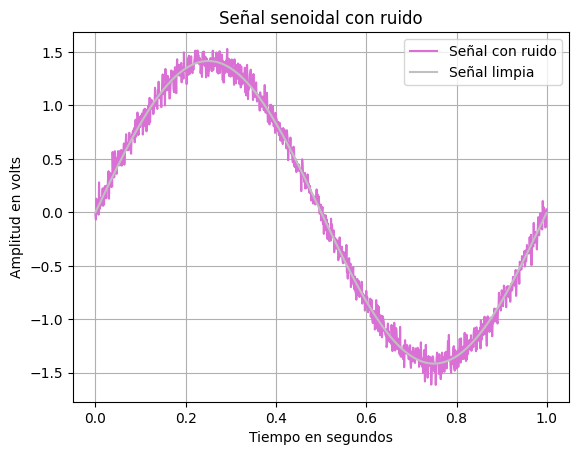

In [47]:
#Importo las libreras con las que voy a trabajar. 

import numpy as np
import matplotlib.pyplot as plt

# Función para generar la señal senoidal. 
def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    ts = 1/fs
    tt = np.arange(nn) * ts
    xx = vmax * np.sin(2*np.pi*ff*tt + ph) + dc
    return tt, xx

# Parámetros de la senoidal
vmax = np.sqrt(2)   # energía unitaria
dc = 0
ff = 1             # frecuencia arbitraria de la senoidal, elijo 50 Hz. 
nn = 1000            # número de muestras
fs = 1000           # frecuencia de muestreo según la consigna. 

# Señal senoidal limpia.
tt, xx = mi_funcion_sen(vmax, dc, ff, ph=0, nn=nn, fs=fs)

# %% Parámetros del ADC para calcular la potencia de cuantización
B = 4               # bits
VF = 2              # Voltios, rango analógico ±VF
q = (2*VF)/(2**B)   # paso de cuantización
Pq = q**2 / 12      # potencia de cuantización
kn = 1              # factor de escala del ruido
Pn = kn * Pq        # potencia del ruido

# %% Ruido aditivo Gaussiano
ruido = np.random.normal(0, np.sqrt(Pn), nn)
yy = xx + ruido     # Defino la señal con ruido. 

# %% Gráfico comparativo
plt.figure()
plt.plot(tt, yy, color='orchid', label='Señal con ruido')
plt.plot(tt, xx, color='silver', label='Señal limpia')
plt.xlabel("Tiempo en segundos")
plt.ylabel("Amplitud en volts")
plt.title("Señal senoidal con ruido")
plt.legend()
plt.grid(True)
plt.show()

**<h5 style="text-align;">SIMULACIÓN DEL ADC + SEÑAL CON RUIDO</h5>**

a) Generar el siguiente resultado producto de la experimentación. B = 4 bits, kn=1.

**AMPLITUD**

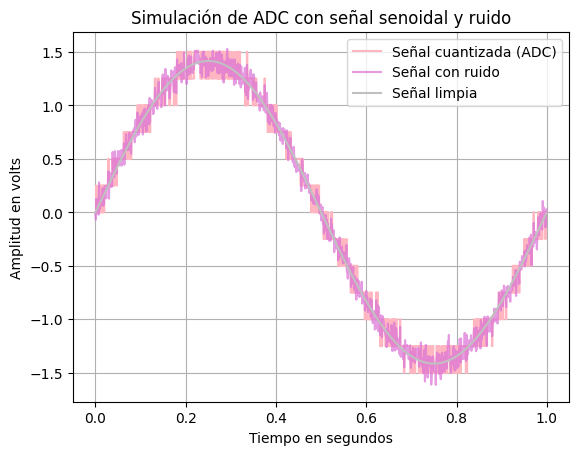

In [48]:
# %% Cuantización (simulación del ADC)
yyq = np.round(yy / q) * q  # Redondeo al nivel más cercano, señal cuantizada.

# %% Gráfico comparativo: señal limpia, con ruido y cuantizada

plt.figure()
plt.step(tt, yyq, color='lightpink', where='mid', label='Señal cuantizada (ADC)')
plt.plot(tt, yy, color='orchid', label='Señal con ruido', alpha=0.7)
plt.plot(tt, xx, color='silver', label='Señal limpia')
plt.xlabel("Tiempo en segundos")
plt.ylabel("Amplitud en volts")
plt.title("Simulación de ADC con señal senoidal y ruido")
plt.legend()
plt.grid(True)
plt.show()

Se puede observar en el gráfico el comportamiento de un ADC de 4bits aplicado a una señal senoidal que posee ruido Gaussiano. 
    La señal senoidal pura, es continua y suave, mientras que la señal modificada, presenta variaciones de forma aleatoria debido al ruido agregado. 
    Cuando la señal es cuantizada, pasando por el ADC, solo se pueden tomar - como se explicó en la introducción - un número finitos de niveles, dando como resultado  un efecto escalonado. La diferencia entre la señal real y la cuantizada  es el error de cuantización ya mencionado y cuya magnitud depende del paso q de cuantización. 

**ERROR DE CUANTIZACIÓN E HISTOGRAMA DEL ERROR DE CUANTIZACIÓN**

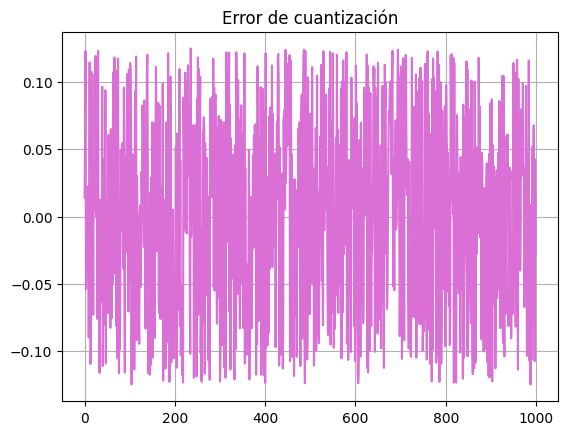

In [49]:
ee = yyq - yy  # error sobre señal con ruido
plt.plot(ee , color='orchid')
plt.grid()
plt.title("Error de cuantización")
plt.show()

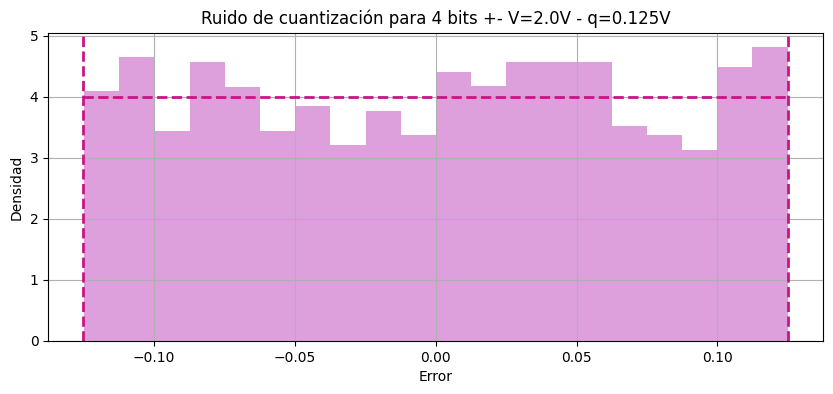

In [50]:
plt.figure(figsize=(10,4))
plt.hist(ee, bins=20, color='plum', density=True) #Tengo que convertirlo a densidad para poder comparar con el valor teórico ideal.

# Límites del error
plt.axvline(-q/2, color='mediumvioletred', linestyle='--', linewidth=2)
plt.axvline(q/2, color='mediumvioletred', linestyle='--', linewidth=2)

# Línea superior, que representa la distribución uniforme ideal.
plt.hlines(1/q, -q/2, q/2, colors='mediumvioletred', linestyles='--', linewidth=2)

plt.title("Ruido de cuantización para 4 bits +- V=2.0V - q=0.125V")
plt.xlabel("Error")
plt.ylabel("Densidad")
plt.grid(True)
plt.show()

El histograma obtenido muestra una distribución aproximadamente uniforme dentro del intervalo -q/2 ; q/2 (las líneas punteadas verticales), sin embargo, se puede observar gracias a la línea punteada superior, pequeñas variaciones frente a la distribución uniforme ideal. 
Dichas variaciones se deben a que la señal de entrada, no es perfectamente uniforme, ya que combina una señal determinista, es decir que se puede predecir su valor en todo momento manteniendo siempre la misma forma, la señal senoidal,  con ruido de tipo gaussiano. 
Aún así, el ruido debido a su carácter incorrelado permite que el error se aproxime a una distribución uniforme. 
Además,  se cumple el modelo de cuantización por redondeo, ya que el error permanece acotado dentro de los límites teóricos ya mencionados. 
La línea horizontal, representa 1/q siendo la referencia de densidad ideal. 

**DENSIDAD ESPECTRAL DE POTENCIA**

LA PSD, Densidad espectral de frecuencias, nos dice cómo está distribuida la potencia de una señal en función de la frecuencia, no solo cuánta potencia tiene la señal, sino también en qué frecuencias se encuentra dicha potencia.

Se calcula a partir de la DFT (Transformada discreta de Fourier) mediante la siguiente expresión:

$$
\mathrm{PSD}[k] = \frac{1}{N} \left| X[k] \right|^2
$$

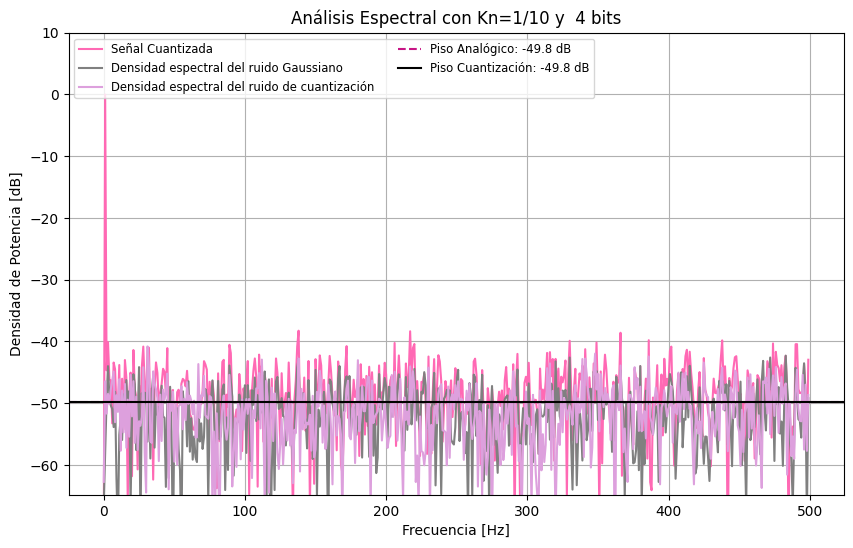

In [51]:
# Calculo las FFT  de las tres señales para luego hacer la comparación.

fft_x  = np.fft.fft(xx)   # Senoidal limpia
fft_y  = np.fft.fft(yy)   # Senoidal más el ruido Gaussiano
fft_yq = np.fft.fft(yyq)  # Senoidal más el ruido Gaussiano  más el ruido de cuantización
fftgauss = np.fft.fft(ruido) # Hago la FFT del ruido Gaussiano solo
fftee = np.fft.fft(ee) # Hago la FFT del ruido de cuantización solo

# Calculo las Frecuencias, pero solo la parte positiva debido a que las negativas carecen de sentido físico.  
freqs = np.fft.fftfreq(nn, d=1/fs)  #Creo un vector con las frecuencias de cada punto de la FFT.
mask = freqs >= 0 #Hago una máscara para que solo estén las frecuencias mayores o iguales a 0. 
fpos = freqs[mask] # Es el eje que voy a usar en el x. 

# Calculo el espectro de potencia normalizado para que el pico sea en 0 dB que equivale a la potencia 1, ya que 10log(1)=0dB
# Tengo que multiplicar por dos, porque uso solo medio espectro. 
def calculardens(f_data, n): #Esto me pareció bueno, me dijo Gemini que podía hacerlo así, porque me había hecho un re lío de código y no me daba ,
    # cuando se lo pasé para que me ayudara a encontrar el error, me lo devolvió creando una función que calcule las dens, y llamarla para cada fft.
    dens = (1/n**2) * np.abs(f_data)**2  #Acá aplico la fórmula que enumeré arrica.
    # Multiplicamos por 2 la parte positiva para mantener energía, lo que expliqué más arriba. 
    dens[1:-1] *= 2  #Los únicos puntos que no tienen espejo con el 0, que es el dc y Nyquist, así que multiplico todos menos esos 
    #el 1 empieza del uno protegiendo el 0 y el -1 que llegue hasta antes del último . 
    return 10 * np.log10(dens[mask] + 1e-12) #Esta parte no me daba, y me puso el 1e-12 y se solucionó, según entendí corrige errores si tenemos log(0)

#Calcula cada densidad

#Calcula cada densidad
calculardensyq  = calculardens(fft_yq, nn)
calculardensgauss = calculardens(fftgauss, nn)
calculardenscuant = calculardens(fftee, nn)
calculardensyy = calculardens(yy, nn)

# %% GRÁFICO COMPARATIVO FINAL
plt.figure(figsize=(10, 6))
# Grafico la densidad espectral de la cuantizada , que es la que tiene todo. 
plt.plot(fpos, calculardensyq, color='hotpink', label='Señal Cuantizada')
# Grafico la densidad espectral del ruido Gaussiano solo.
plt.plot(fpos, calculardensgauss, color='gray', label='Densidad espectral del ruido Gaussiano')
# Gracuco la densidqad espectral del ruido de cuantización solo.
plt.plot(fpos, calculardenscuant, color='plum', label='Densidad espectral del ruido de cuantización')

# AHORA HAGO LOS PISOS TEÓRICOS

# Para el piso analógico teórico uso solo el Pn
piso_an_teorico = 10 * np.log10(Pn / (nn/2))
plt.axhline(piso_an_teorico, color='mediumvioletred', linestyle='--', label=f'Piso Analógico: {piso_an_teorico:.1f} dB')

# Para el piso de cuantización teórico uso solo el Pq
piso_q_teorico = 10 * np.log10(Pq / (nn/2))
plt.axhline(piso_q_teorico, color='black', label=f'Piso Cuantización: {piso_q_teorico:.1f} dB')

# GRAFICO 
plt.title("Análisis Espectral con Kn=1/10 y  4 bits")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad de Potencia [dB]")

# Ajusto el límite para que se vean bien los pisos 
plt.ylim([min(piso_an_teorico, piso_q_teorico) - 15, 10]) 
plt.legend(loc='upper left', fontsize='small', ncol=2)
plt.grid(True)
plt.show()

La línea rosa que se observa, es la de la senoidal pura, tiene un pico muy alto en la frecuencia cercana a 0-1 Hz, como la normalicé para que tenga energía unitaria, el pico toca exactamente los 0 dB, por lo que se puede asumir que la fft está bien calculada y la densidad bien escalada.  

La señal cuantizada se encuentra por encima de la señal senoidal con ruido, esto tiene sentido debido a que se le suma un error más - del ADC- al que ya había , como Kn=1 la potencia del ruido analógico es igual al de cuantización, es sabido que cuando se suman dos ruidos "iguales" suben 3dB, puede ser debido a ello.

La línea negra, representa el "umbral de silencio" o sea que toda señal que sea más pequeña que  -49.8dB se perderá, esto puede ocurrir debido a que el ADC simulado solo tiene 4 bits, y un paso bastante grande, si fuera más grande, el piso lila debería bajar, ya que tendríamos una señal  más limpia.

Por último, el ruido blanco está desparramado desde el 0 al 500 Hz, o sea que se distribuye uniformemente en todo el espector, no hay picos más notablemente más altos en ciertas frecuencias, confirmando que el ruido es blanco e incorrelado.  

b) Analizar para una de las siguientes configuraciones B = ̣{4, 8 y 16} bits, kn={1/10,1,10}.Discutir los resultados respecto a lo obtenido en a).

- Caso A.1 : B=4 y Kn=1/10

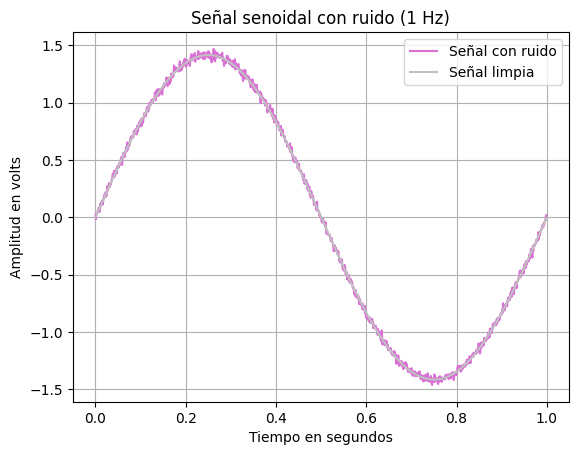

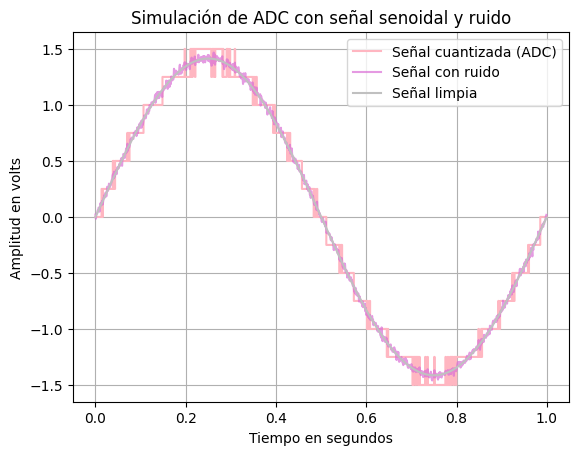

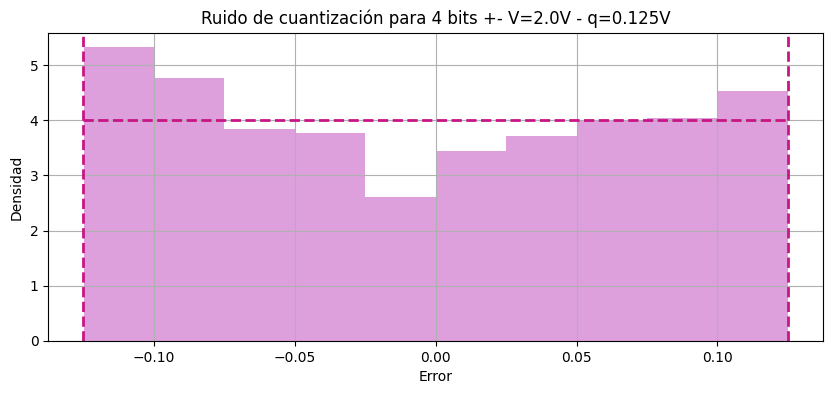

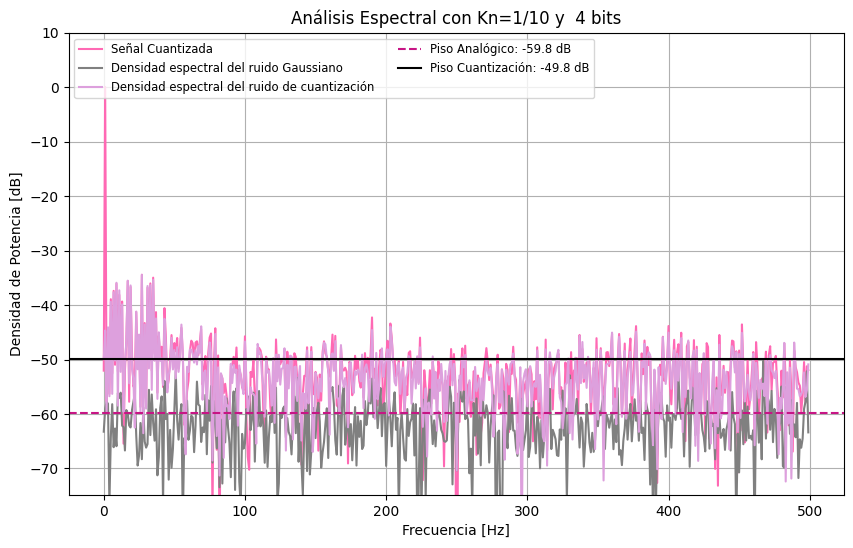

In [29]:
# %% Parámetros del ADC para calcular la potencia de cuantización
B = 4                # bits
VF = 2               # Voltios, rango analógico ±VF
q = (2*VF)/(2**B)    # paso de cuantización
Pq = q**2 / 12       # potencia de cuantización
kn = 1/10               # factor de escala del ruido
Pn = kn * Pq         # potencia del ruido

# %% Ruido aditivo Gaussiano
ruido = np.random.normal(0, np.sqrt(Pn), nn)
yy = xx + ruido     # Defino la señal con ruido. 


plt.figure()
plt.plot(tt, yy, color='orchid', label='Señal con ruido')
plt.plot(tt, xx, color='silver', label='Señal limpia')
plt.xlabel("Tiempo en segundos")
plt.ylabel("Amplitud en volts")
plt.title(f"Señal senoidal con ruido ({ff} Hz)")
plt.legend()
plt.grid(True)
plt.show()

# Cuantización (simulación del ADC)
yyq = np.round(yy / q) * q  # Redondeo al nivel más cercano, señal cuantizada.

# %% Gráfico comparativo: señal limpia, con ruido y cuantizada
plt.figure()
plt.step(tt, yyq, color='lightpink', where='mid', label='Señal cuantizada (ADC)')
plt.plot(tt, yy, color='orchid', label='Señal con ruido', alpha=0.7)
plt.plot(tt, xx, color='silver', label='Señal limpia')
plt.xlabel("Tiempo en segundos")
plt.ylabel("Amplitud en volts")
plt.title("Simulación de ADC con señal senoidal y ruido")
plt.legend()
plt.grid(True)
plt.show()

#%% ERROR 
ee = yyq - yy  # error sobre señal con ruido

plt.figure(figsize=(10,4))
plt.hist(ee, bins=10, color='plum', density=True) 

# Límites del error
plt.axvline(-q/2, color='mediumvioletred', linestyle='--', linewidth=2)
plt.axvline(q/2, color='mediumvioletred', linestyle='--', linewidth=2)
plt.hlines(1/q, -q/2, q/2, colors='mediumvioletred', linestyles='--', linewidth=2)

plt.title("Ruido de cuantización para 4 bits +- V=2.0V - q=0.125V")
plt.xlabel("Error")
plt.ylabel("Densidad")
plt.grid(True)
plt.show()

# Calculo las FFT de las tres señales
fft_x  = np.fft.fft(xx)   
fft_y  = np.fft.fft(yy)   
fft_yq = np.fft.fft(yyq)  
fftgauss = np.fft.fft(ruido) # Hago la FFT del ruido Gaussiano solo
fftee = np.fft.fft(ee) # Hago la FFT del ruido de cuantización solo


freqs = np.fft.fftfreq(nn, d=1/fs)
mask = freqs >= 0 
fpos = freqs[mask]

def calculardens(f_data, n): 
    dens = (1/n**2) * np.abs(f_data)**2  
    dens[1:-1] *= 2  
    return 10 * np.log10(dens[mask] + 1e-12) 


#Calcula cada densidad
calculardensyq  = calculardens(fft_yq, nn)
calculardensgauss = calculardens(fftgauss, nn)
calculardenscuant = calculardens(fftee, nn)
calculardensyy = calculardens(yy, nn)


# %% GRÁFICO COMPARATIVO FINAL
plt.figure(figsize=(10, 6))

# Grafico la densidad espectral de la cuantizada , que es la que tiene todo. 
plt.plot(fpos, calculardensyq, color='hotpink', label='Señal Cuantizada')

# Grafico la densidad espectral del ruido Gaussiano solo.
plt.plot(fpos, calculardensgauss, color='gray', label='Densidad espectral del ruido Gaussiano')

# Gracuco la densidqad espectral del ruido de cuantización solo.
plt.plot(fpos, calculardenscuant, color='plum', label='Densidad espectral del ruido de cuantización')

# AHORA HAGO LOS PISOS TEÓRICOS

# Para el piso analógico teórico uso solo el Pn
piso_an_teorico = 10 * np.log10(Pn / (nn/2))
plt.axhline(piso_an_teorico, color='mediumvioletred', linestyle='--', label=f'Piso Analógico: {piso_an_teorico:.1f} dB')

# Para el piso de cuantización teórico uso solo el Pq
piso_q_teorico = 10 * np.log10(Pq / (nn/2))
plt.axhline(piso_q_teorico, color='black', label=f'Piso Cuantización: {piso_q_teorico:.1f} dB')

# GRAFICO 
plt.title("Análisis Espectral con Kn=1/10 y  4 bits")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad de Potencia [dB]")

# Ajusto el límite para que se vean bien los pisos 
plt.ylim([min(piso_an_teorico, piso_q_teorico) - 15, 10]) 
plt.legend(loc='upper left', fontsize='small', ncol=2)
plt.grid(True)
plt.show()

En el segundo gráfico, correspondiente a la señal en el tiempo, se observan tres curvas, por un lado la señal senoidal gris, que sería la ideal, la señal con ruido y la señal cuantizada. 
La señal ideal, es limpia y representa la referencia sin perturbaciones, mientras que la señal con ruido incorpora una componente aleatoria cuya potencia es baja. Luego tenemos la señal cuantizada, que se ve escalonada. 

En el segundo gráfico, correspondiente al histograma del error de cuantización, se observa que el error está acotado en el intervalo -q/2 y q/2,  presentando una distribución aproximadamente uniforme. Además, la densidad coincide razonablemente con el valor teórico que era 1/q.

En el tercer gráfico, donde  se analiza la densidad espectral de potencia, se identifica un gran pico rosado, que corresponde a la frecuencia de la señal senoidal ideal, mientras que el resto del espectro presenta un piso de ruido aproximadamente plano, que ya se dijo en clase que es típicp de un ruido blanco.

El piso de ruido de cuantización (lila) se encuentra por encima del analógico (gris) esto tiene sentido ya que con kn=1/10, el ruido analógico está 10 dB por debajo del ruido de cuantización.
En consecuencia, el sistema se encuentra limitado por el ruido de cuantización, ya que este constituye la principal contribución al ruido total, luego cuando se simule con más bits, debería cambiar.

- Caso A.2 : B=4 y Kn=1

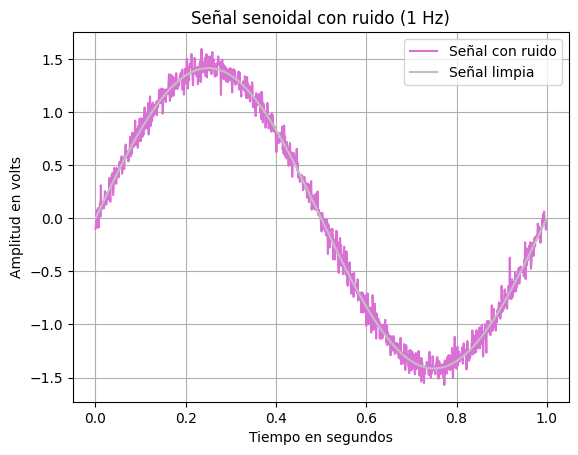

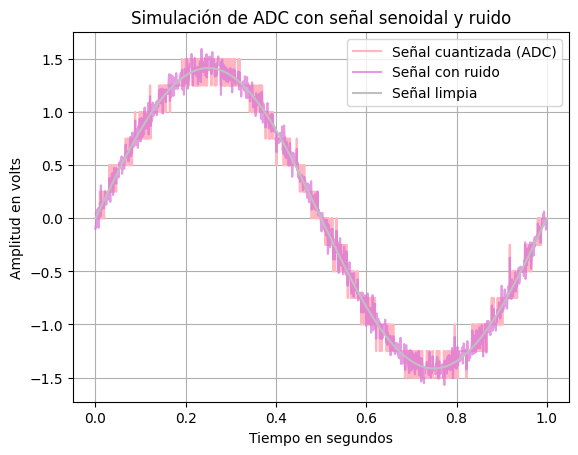

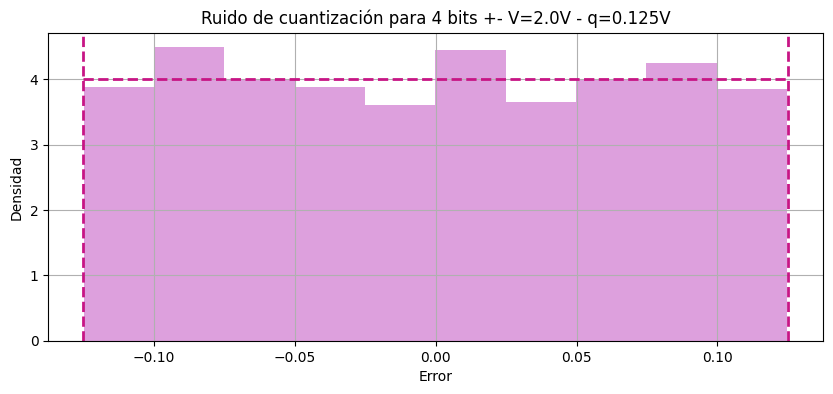

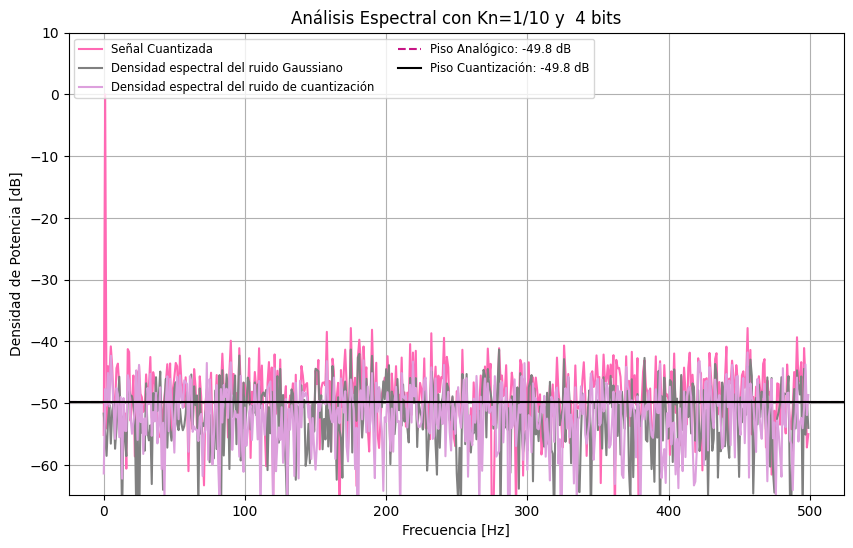

In [31]:
# %% Parámetros del ADC para calcular la potencia de cuantización
B = 4                # bits
VF = 2               # Voltios, rango analógico ±VF
q = (2*VF)/(2**B)    # paso de cuantización
Pq = q**2 / 12       # potencia de cuantización
kn = 1              # factor de escala del ruido
Pn = kn * Pq         # potencia del ruido

# %% Ruido aditivo Gaussiano
ruido = np.random.normal(0, np.sqrt(Pn), nn)
yy = xx + ruido     # Defino la señal con ruido. 


plt.figure()
plt.plot(tt, yy, color='orchid', label='Señal con ruido')
plt.plot(tt, xx, color='silver', label='Señal limpia')
plt.xlabel("Tiempo en segundos")
plt.ylabel("Amplitud en volts")
plt.title(f"Señal senoidal con ruido ({ff} Hz)")
plt.legend()
plt.grid(True)
plt.show()

# Cuantización (simulación del ADC)
yyq = np.round(yy / q) * q  # Redondeo al nivel más cercano, señal cuantizada.

# %% Gráfico comparativo: señal limpia, con ruido y cuantizada
plt.figure()
plt.step(tt, yyq, color='lightpink', where='mid', label='Señal cuantizada (ADC)')
plt.plot(tt, yy, color='orchid', label='Señal con ruido', alpha=0.7)
plt.plot(tt, xx, color='silver', label='Señal limpia')
plt.xlabel("Tiempo en segundos")
plt.ylabel("Amplitud en volts")
plt.title("Simulación de ADC con señal senoidal y ruido")
plt.legend()
plt.grid(True)
plt.show()

#%% ERROR 
ee = yyq - yy  # error sobre señal con ruido

plt.figure(figsize=(10,4))
plt.hist(ee, bins=10, color='plum', density=True) 

# Límites del error
plt.axvline(-q/2, color='mediumvioletred', linestyle='--', linewidth=2)
plt.axvline(q/2, color='mediumvioletred', linestyle='--', linewidth=2)
plt.hlines(1/q, -q/2, q/2, colors='mediumvioletred', linestyles='--', linewidth=2)

plt.title("Ruido de cuantización para 4 bits +- V=2.0V - q=0.125V")
plt.xlabel("Error")
plt.ylabel("Densidad")
plt.grid(True)
plt.show()

# Calculo las FFT de las tres señales
fft_x  = np.fft.fft(xx)   
fft_y  = np.fft.fft(yy)   
fft_yq = np.fft.fft(yyq)  
fftgauss = np.fft.fft(ruido) # Hago la FFT del ruido Gaussiano solo
fftee = np.fft.fft(ee) # Hago la FFT del ruido de cuantización solo


freqs = np.fft.fftfreq(nn, d=1/fs)
mask = freqs >= 0 
fpos = freqs[mask]

def calculardens(f_data, n): 
    dens = (1/n**2) * np.abs(f_data)**2  
    dens[1:-1] *= 2  
    return 10 * np.log10(dens[mask] + 1e-12) 


#Calcula cada densidad
calculardensyq  = calculardens(fft_yq, nn)
calculardensgauss = calculardens(fftgauss, nn)
calculardenscuant = calculardens(fftee, nn)
calculardensyy = calculardens(yy, nn)


# %% GRÁFICO COMPARATIVO FINAL
plt.figure(figsize=(10, 6))

# Grafico la densidad espectral de la cuantizada , que es la que tiene todo. 
plt.plot(fpos, calculardensyq, color='hotpink', label='Señal Cuantizada')

# Grafico la densidad espectral del ruido Gaussiano solo.
plt.plot(fpos, calculardensgauss, color='gray', label='Densidad espectral del ruido Gaussiano')

# Gracuco la densidqad espectral del ruido de cuantización solo.
plt.plot(fpos, calculardenscuant, color='plum', label='Densidad espectral del ruido de cuantización')

# AHORA HAGO LOS PISOS TEÓRICOS

# Para el piso analógico teórico uso solo el Pn
piso_an_teorico = 10 * np.log10(Pn / (nn/2))
plt.axhline(piso_an_teorico, color='mediumvioletred', linestyle='--', label=f'Piso Analógico: {piso_an_teorico:.1f} dB')

# Para el piso de cuantización teórico uso solo el Pq
piso_q_teorico = 10 * np.log10(Pq / (nn/2))
plt.axhline(piso_q_teorico, color='black', label=f'Piso Cuantización: {piso_q_teorico:.1f} dB')

# GRAFICO 
plt.title("Análisis Espectral con Kn=1/10 y  4 bits")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad de Potencia [dB]")

# Ajusto el límite para que se vean bien los pisos 
plt.ylim([min(piso_an_teorico, piso_q_teorico) - 15, 10]) 
plt.legend(loc='upper left', fontsize='small', ncol=2)
plt.grid(True)
plt.show()

A diferencia del anterior, la señal analógica presenta mayor ruido, luego en el gráfico de la sensidad de potencias, se puede observar que ambos ruidos se encuentran "pisándose" esto tiene concordancia con la relación de Kn=1, ya que ambas potencias son iguales.

- Caso A.3 : B=4 y Kn=10

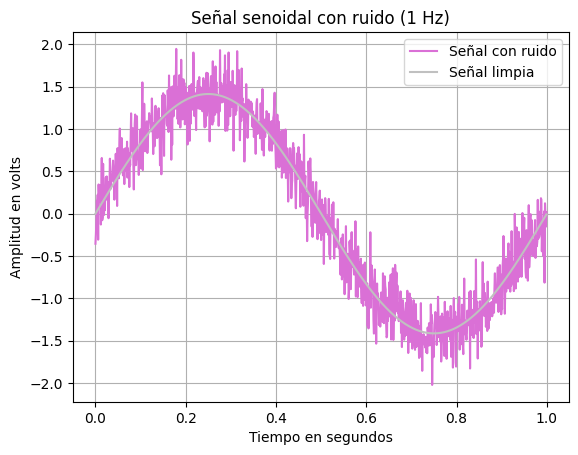

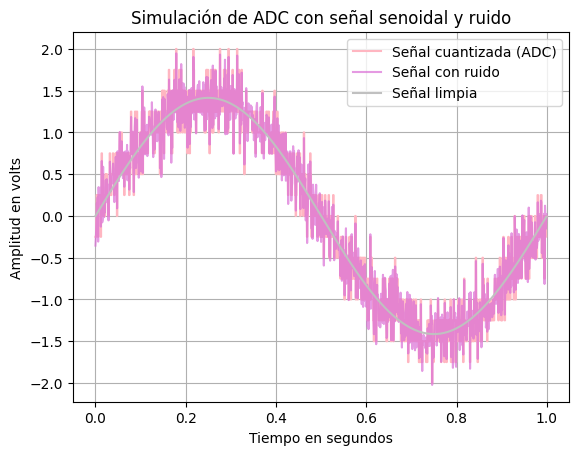

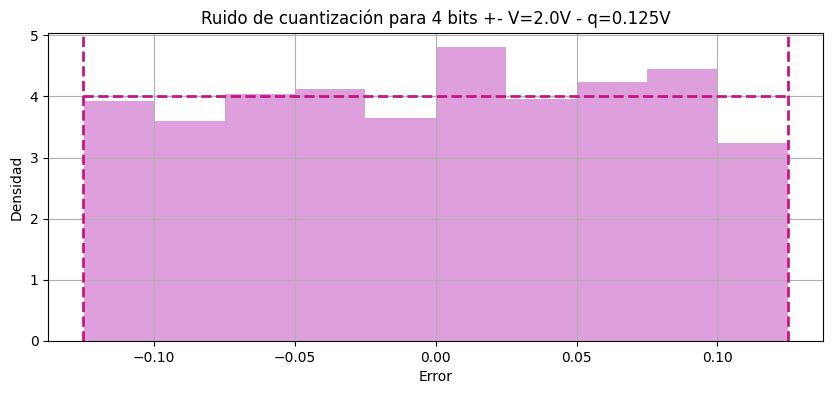

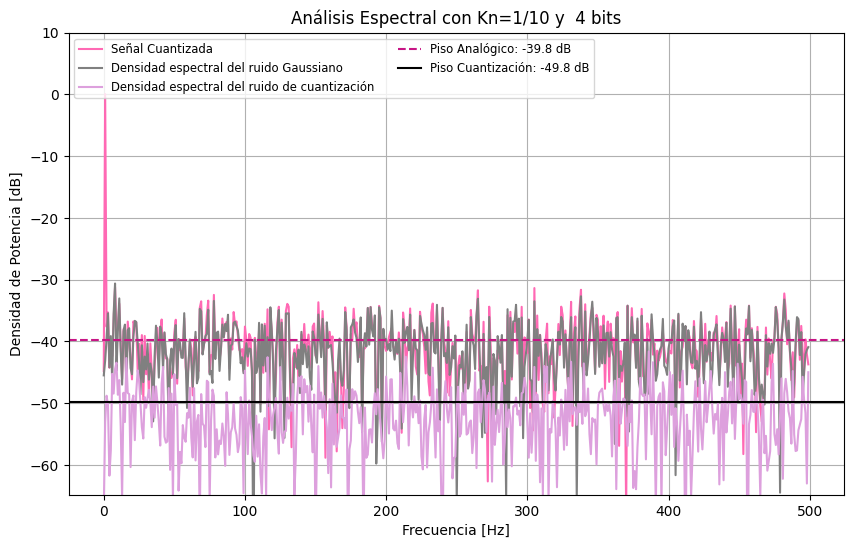

In [33]:
# %% Parámetros del ADC para calcular la potencia de cuantización
B = 4                # bits
VF = 2               # Voltios, rango analógico ±VF
q = (2*VF)/(2**B)    # paso de cuantización
Pq = q**2 / 12       # potencia de cuantización
kn = 10              # factor de escala del ruido
Pn = kn * Pq         # potencia del ruido

# %% Ruido aditivo Gaussiano
ruido = np.random.normal(0, np.sqrt(Pn), nn)
yy = xx + ruido     # Defino la señal con ruido. 


plt.figure()
plt.plot(tt, yy, color='orchid', label='Señal con ruido')
plt.plot(tt, xx, color='silver', label='Señal limpia')
plt.xlabel("Tiempo en segundos")
plt.ylabel("Amplitud en volts")
plt.title(f"Señal senoidal con ruido ({ff} Hz)")
plt.legend()
plt.grid(True)
plt.show()

# Cuantización (simulación del ADC)
yyq = np.round(yy / q) * q  # Redondeo al nivel más cercano, señal cuantizada.

# %% Gráfico comparativo: señal limpia, con ruido y cuantizada
plt.figure()
plt.step(tt, yyq, color='lightpink', where='mid', label='Señal cuantizada (ADC)')
plt.plot(tt, yy, color='orchid', label='Señal con ruido', alpha=0.7)
plt.plot(tt, xx, color='silver', label='Señal limpia')
plt.xlabel("Tiempo en segundos")
plt.ylabel("Amplitud en volts")
plt.title("Simulación de ADC con señal senoidal y ruido")
plt.legend()
plt.grid(True)
plt.show()

#%% ERROR 
ee = yyq - yy  # error sobre señal con ruido

plt.figure(figsize=(10,4))
plt.hist(ee, bins=10, color='plum', density=True) 

# Límites del error
plt.axvline(-q/2, color='mediumvioletred', linestyle='--', linewidth=2)
plt.axvline(q/2, color='mediumvioletred', linestyle='--', linewidth=2)
plt.hlines(1/q, -q/2, q/2, colors='mediumvioletred', linestyles='--', linewidth=2)

plt.title("Ruido de cuantización para 4 bits +- V=2.0V - q=0.125V")
plt.xlabel("Error")
plt.ylabel("Densidad")
plt.grid(True)
plt.show()

# Calculo las FFT de las tres señales
fft_x  = np.fft.fft(xx)   
fft_y  = np.fft.fft(yy)   
fft_yq = np.fft.fft(yyq)  
fftgauss = np.fft.fft(ruido) # Hago la FFT del ruido Gaussiano solo
fftee = np.fft.fft(ee) # Hago la FFT del ruido de cuantización solo


freqs = np.fft.fftfreq(nn, d=1/fs)
mask = freqs >= 0 
fpos = freqs[mask]

def calculardens(f_data, n): 
    dens = (1/n**2) * np.abs(f_data)**2  
    dens[1:-1] *= 2  
    return 10 * np.log10(dens[mask] + 1e-12) 


#Calcula cada densidad
calculardensyq  = calculardens(fft_yq, nn)
calculardensgauss = calculardens(fftgauss, nn)
calculardenscuant = calculardens(fftee, nn)
calculardensyy = calculardens(yy, nn)


# %% GRÁFICO COMPARATIVO FINAL
plt.figure(figsize=(10, 6))

# Grafico la densidad espectral de la cuantizada , que es la que tiene todo. 
plt.plot(fpos, calculardensyq, color='hotpink', label='Señal Cuantizada')

# Grafico la densidad espectral del ruido Gaussiano solo.
plt.plot(fpos, calculardensgauss, color='gray', label='Densidad espectral del ruido Gaussiano')

# Gracuco la densidqad espectral del ruido de cuantización solo.
plt.plot(fpos, calculardenscuant, color='plum', label='Densidad espectral del ruido de cuantización')

# AHORA HAGO LOS PISOS TEÓRICOS

# Para el piso analógico teórico uso solo el Pn
piso_an_teorico = 10 * np.log10(Pn / (nn/2))
plt.axhline(piso_an_teorico, color='mediumvioletred', linestyle='--', label=f'Piso Analógico: {piso_an_teorico:.1f} dB')

# Para el piso de cuantización teórico uso solo el Pq
piso_q_teorico = 10 * np.log10(Pq / (nn/2))
plt.axhline(piso_q_teorico, color='black', label=f'Piso Cuantización: {piso_q_teorico:.1f} dB')

# GRAFICO 
plt.title("Análisis Espectral con Kn=1/10 y  4 bits")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad de Potencia [dB]")

# Ajusto el límite para que se vean bien los pisos 
plt.ylim([min(piso_an_teorico, piso_q_teorico) - 15, 10]) 
plt.legend(loc='upper left', fontsize='small', ncol=2)
plt.grid(True)
plt.show()

A diferencia de los gráficos anteriores, cuando Kn=10, la potencia del ruido analógico cumple  es 10 veces mayor que la potencia del ruido de cuantización, o sea que en términos de dB, e el piso de ruido analógico se encuentra aproximadamente 10 dB por encima del piso de cuantización.

- Caso B: B = 8 Bits y Kn = 1/10 

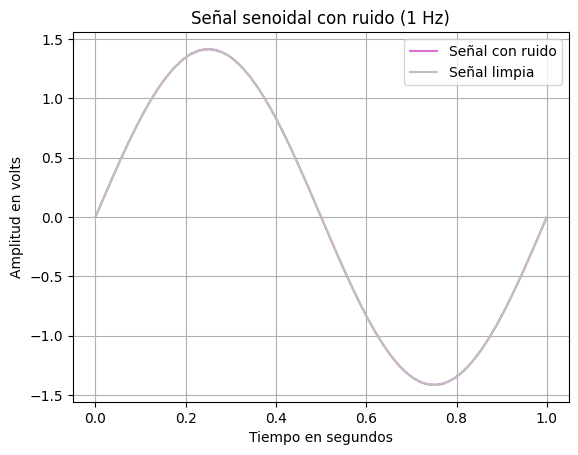

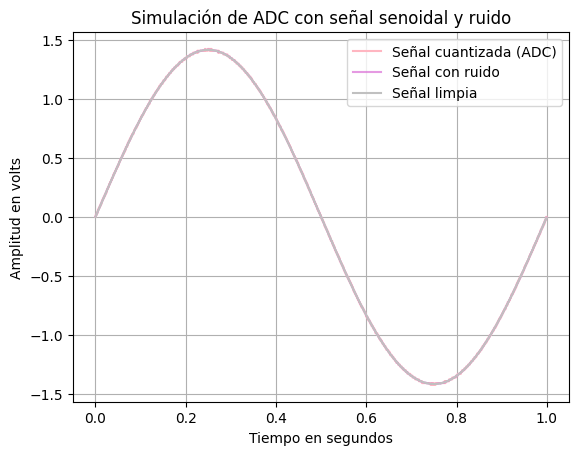

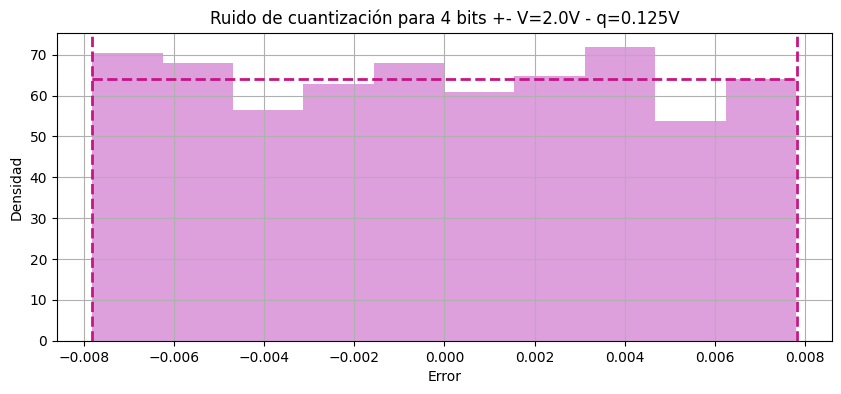

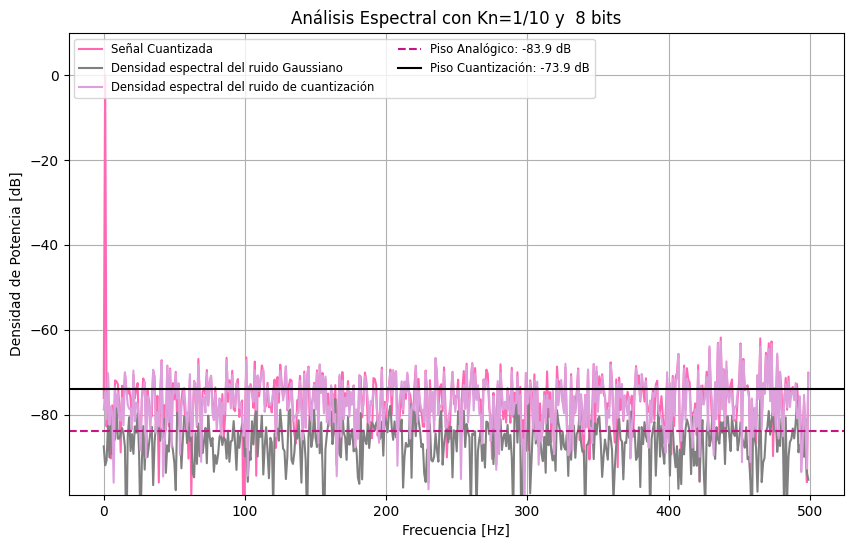

In [41]:
# %% Parámetros del ADC para calcular la potencia de cuantización
B = 8                # bits
VF = 2               # Voltios, rango analógico ±VF
q = (2*VF)/(2**B)    # paso de cuantización
Pq = q**2 / 12       # potencia de cuantización
kn = 1/10              # factor de escala del ruido
Pn = kn * Pq         # potencia del ruido

# %% Ruido aditivo Gaussiano
ruido = np.random.normal(0, np.sqrt(Pn), nn)
yy = xx + ruido     # Defino la señal con ruido. 


plt.figure()
plt.plot(tt, yy, color='orchid', label='Señal con ruido')
plt.plot(tt, xx, color='silver', label='Señal limpia')
plt.xlabel("Tiempo en segundos")
plt.ylabel("Amplitud en volts")
plt.title(f"Señal senoidal con ruido ({ff} Hz)")
plt.legend()
plt.grid(True)
plt.show()

# Cuantización (simulación del ADC)
yyq = np.round(yy / q) * q  # Redondeo al nivel más cercano, señal cuantizada.

# %% Gráfico comparativo: señal limpia, con ruido y cuantizada
plt.figure()
plt.step(tt, yyq, color='lightpink', where='mid', label='Señal cuantizada (ADC)')
plt.plot(tt, yy, color='orchid', label='Señal con ruido', alpha=0.7)
plt.plot(tt, xx, color='silver', label='Señal limpia')
plt.xlabel("Tiempo en segundos")
plt.ylabel("Amplitud en volts")
plt.title("Simulación de ADC con señal senoidal y ruido")
plt.legend()
plt.grid(True)
plt.show()

#%% ERROR 
ee = yyq - yy  # error sobre señal con ruido

plt.figure(figsize=(10,4))
plt.hist(ee, bins=10, color='plum', density=True) 

# Límites del error
plt.axvline(-q/2, color='mediumvioletred', linestyle='--', linewidth=2)
plt.axvline(q/2, color='mediumvioletred', linestyle='--', linewidth=2)
plt.hlines(1/q, -q/2, q/2, colors='mediumvioletred', linestyles='--', linewidth=2)

plt.title("Ruido de cuantización para 4 bits +- V=2.0V - q=0.125V")
plt.xlabel("Error")
plt.ylabel("Densidad")
plt.grid(True)
plt.show()

# Calculo las FFT de las tres señales
fft_x  = np.fft.fft(xx)   
fft_y  = np.fft.fft(yy)   
fft_yq = np.fft.fft(yyq)  
fftgauss = np.fft.fft(ruido) # Hago la FFT del ruido Gaussiano solo
fftee = np.fft.fft(ee) # Hago la FFT del ruido de cuantización solo


freqs = np.fft.fftfreq(nn, d=1/fs)
mask = freqs >= 0 
fpos = freqs[mask]

def calculardens(f_data, n): 
    dens = (1/n**2) * np.abs(f_data)**2  
    dens[1:-1] *= 2  
    return 10 * np.log10(dens[mask] + 1e-12) 


#Calcula cada densidad
calculardensyq  = calculardens(fft_yq, nn)
calculardensgauss = calculardens(fftgauss, nn)
calculardenscuant = calculardens(fftee, nn)
calculardensyy = calculardens(yy, nn)


# %% GRÁFICO COMPARATIVO FINAL
plt.figure(figsize=(10, 6))

# Grafico la densidad espectral de la cuantizada , que es la que tiene todo. 
plt.plot(fpos, calculardensyq, color='hotpink', label='Señal Cuantizada')

# Grafico la densidad espectral del ruido Gaussiano solo.
plt.plot(fpos, calculardensgauss, color='gray', label='Densidad espectral del ruido Gaussiano')

# Gracuco la densidqad espectral del ruido de cuantización solo.
plt.plot(fpos, calculardenscuant, color='plum', label='Densidad espectral del ruido de cuantización')

# AHORA HAGO LOS PISOS TEÓRICOS

# Para el piso analógico teórico uso solo el Pn
piso_an_teorico = 10 * np.log10(Pn / (nn/2))
plt.axhline(piso_an_teorico, color='mediumvioletred', linestyle='--', label=f'Piso Analógico: {piso_an_teorico:.1f} dB')

# Para el piso de cuantización teórico uso solo el Pq
piso_q_teorico = 10 * np.log10(Pq / (nn/2))
plt.axhline(piso_q_teorico, color='black', label=f'Piso Cuantización: {piso_q_teorico:.1f} dB')

# GRAFICO 
plt.title("Análisis Espectral con Kn=1/10 y  8 bits")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad de Potencia [dB]")

# Ajusto el límite para que se vean bien los pisos 
plt.ylim([min(piso_an_teorico, piso_q_teorico) - 15, 10]) 
plt.legend(loc='upper left', fontsize='small', ncol=2) #Lo pongo arribita a la derecha para que no me moleste, y con ncol los pongo en 2 columnas.
plt.grid(True)
plt.show()

En este caso, el ADC posee una resolución mayor, lo que reduce significativamente el paso de cuantización, sin embargo, como Kn = 1/12 el ruido analógico es menor que el ruido de cuantización.

Sin embardo, la señal cuantizada, a diferencia de cuando el ADC era de 4 bits,  se observa  más cercana a la señal limpia, ya que el menor tamaño de cuantización reduce notablemente el error introducido por el ADC. 

El histograma del error sigue mostrando una distribución aproximadamente uniforme en el intervalo.

En el análisis espectral, se observa un piso de ruido más bajo en comparación con el caso de 4 bits, debido principalmente a la reducción de la potencia de cuantización al aumentar la resolución. El ruido de cuantización continúa siendo la componente dominante del sistema.

- Caso B.2: B = 8 bits y Kn=1

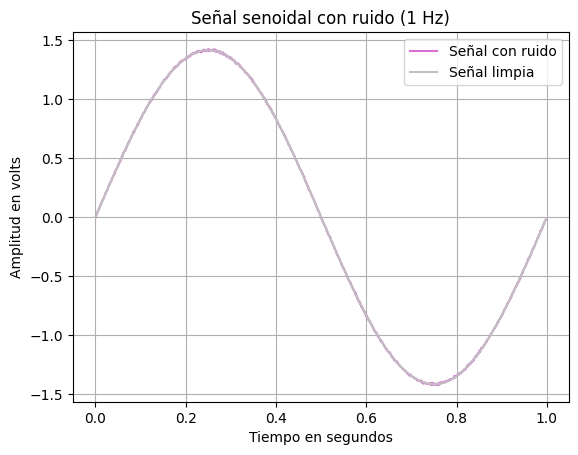

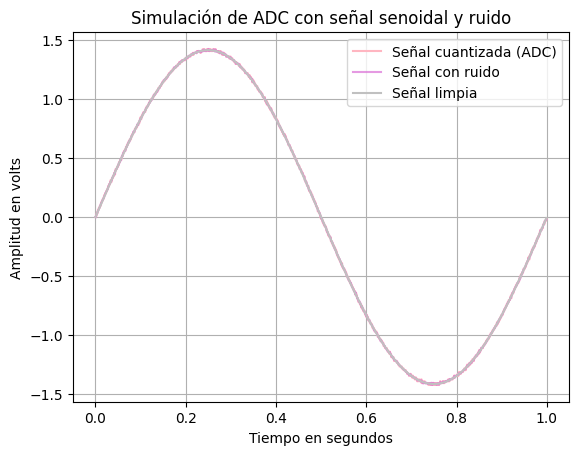

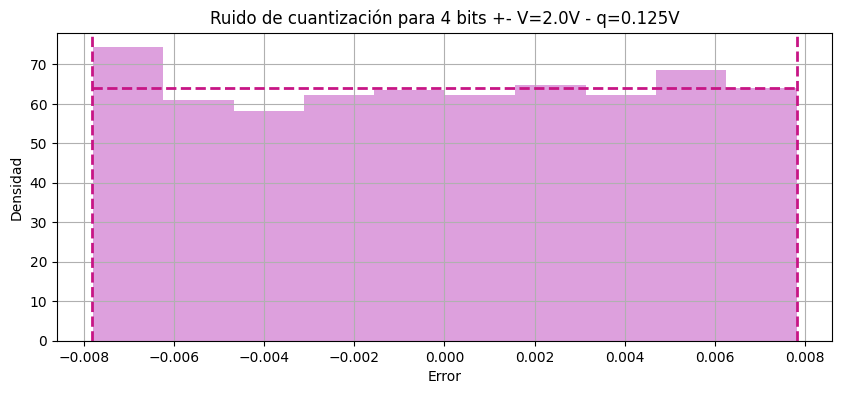

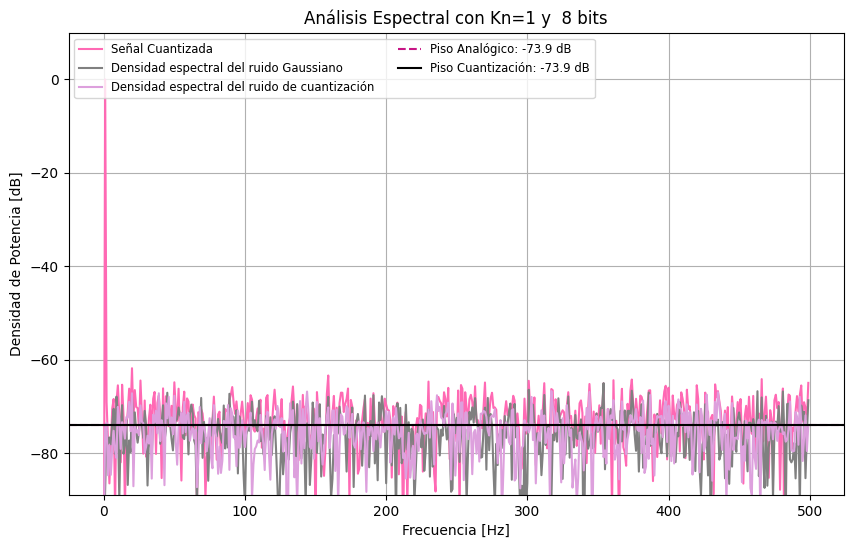

In [40]:
# %% Parámetros del ADC para calcular la potencia de cuantización
B = 8                # bits
VF = 2               # Voltios, rango analógico ±VF
q = (2*VF)/(2**B)    # paso de cuantización
Pq = q**2 / 12       # potencia de cuantización
kn = 1              # factor de escala del ruido
Pn = kn * Pq         # potencia del ruido

# %% Ruido aditivo Gaussiano
ruido = np.random.normal(0, np.sqrt(Pn), nn)
yy = xx + ruido     # Defino la señal con ruido. 


plt.figure()
plt.plot(tt, yy, color='orchid', label='Señal con ruido')
plt.plot(tt, xx, color='silver', label='Señal limpia')
plt.xlabel("Tiempo en segundos")
plt.ylabel("Amplitud en volts")
plt.title(f"Señal senoidal con ruido ({ff} Hz)")
plt.legend()
plt.grid(True)
plt.show()

# Cuantización (simulación del ADC)
yyq = np.round(yy / q) * q  # Redondeo al nivel más cercano, señal cuantizada.

# %% Gráfico comparativo: señal limpia, con ruido y cuantizada
plt.figure()
plt.step(tt, yyq, color='lightpink', where='mid', label='Señal cuantizada (ADC)')
plt.plot(tt, yy, color='orchid', label='Señal con ruido', alpha=0.7)
plt.plot(tt, xx, color='silver', label='Señal limpia')
plt.xlabel("Tiempo en segundos")
plt.ylabel("Amplitud en volts")
plt.title("Simulación de ADC con señal senoidal y ruido")
plt.legend()
plt.grid(True)
plt.show()

#%% ERROR 
ee = yyq - yy  # error sobre señal con ruido

plt.figure(figsize=(10,4))
plt.hist(ee, bins=10, color='plum', density=True) 

# Límites del error
plt.axvline(-q/2, color='mediumvioletred', linestyle='--', linewidth=2)
plt.axvline(q/2, color='mediumvioletred', linestyle='--', linewidth=2)
plt.hlines(1/q, -q/2, q/2, colors='mediumvioletred', linestyles='--', linewidth=2)

plt.title("Ruido de cuantización para 4 bits +- V=2.0V - q=0.125V")
plt.xlabel("Error")
plt.ylabel("Densidad")
plt.grid(True)
plt.show()

# Calculo las FFT de las tres señales
fft_x  = np.fft.fft(xx)   
fft_y  = np.fft.fft(yy)   
fft_yq = np.fft.fft(yyq)  
fftgauss = np.fft.fft(ruido) # Hago la FFT del ruido Gaussiano solo
fftee = np.fft.fft(ee) # Hago la FFT del ruido de cuantización solo


freqs = np.fft.fftfreq(nn, d=1/fs)
mask = freqs >= 0 
fpos = freqs[mask]

def calculardens(f_data, n): 
    dens = (1/n**2) * np.abs(f_data)**2  
    dens[1:-1] *= 2  
    return 10 * np.log10(dens[mask] + 1e-12) 


#Calcula cada densidad
calculardensyq  = calculardens(fft_yq, nn)
calculardensgauss = calculardens(fftgauss, nn)
calculardenscuant = calculardens(fftee, nn)
calculardensyy = calculardens(yy, nn)


# %% GRÁFICO COMPARATIVO FINAL
plt.figure(figsize=(10, 6))

# Grafico la densidad espectral de la cuantizada , que es la que tiene todo. 
plt.plot(fpos, calculardensyq, color='hotpink', label='Señal Cuantizada')

# Grafico la densidad espectral del ruido Gaussiano solo.
plt.plot(fpos, calculardensgauss, color='gray', label='Densidad espectral del ruido Gaussiano')

# Gracuco la densidqad espectral del ruido de cuantización solo.
plt.plot(fpos, calculardenscuant, color='plum', label='Densidad espectral del ruido de cuantización')

# AHORA HAGO LOS PISOS TEÓRICOS

# Para el piso analógico teórico uso solo el Pn
piso_an_teorico = 10 * np.log10(Pn / (nn/2))
plt.axhline(piso_an_teorico, color='mediumvioletred', linestyle='--', label=f'Piso Analógico: {piso_an_teorico:.1f} dB')

# Para el piso de cuantización teórico uso solo el Pq
piso_q_teorico = 10 * np.log10(Pq / (nn/2))
plt.axhline(piso_q_teorico, color='black', label=f'Piso Cuantización: {piso_q_teorico:.1f} dB')

# GRAFICO 
plt.title("Análisis Espectral con Kn=1 y  8 bits")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad de Potencia [dB]")

# Ajusto el límite para que se vean bien los pisos 
plt.ylim([min(piso_an_teorico, piso_q_teorico) - 15, 10]) 
plt.legend(loc='upper left', fontsize='small', ncol=2) #Lo pongo arribita a la derecha para que no me moleste, y con ncol los pongo en 2 columnas.
plt.grid(True)
plt.show()

El nuevo paso de cuantización es : 

Con 4 bits tenía: $$2^4 = 16$$ niveles.

Con 8 bits tenía: $$2^8 = 256$$ niveles.

Disminuyó tanto el ruido de cuantización gracias a que ahora el paso de cuantización es minúsculo, que se "pegó" al ruido Gaussiano, ya casi  no adhiere ruido, sino que se ve el que la señal digitalizada arrastraba.

- Caso B: B= 8 bits y Kn = 10

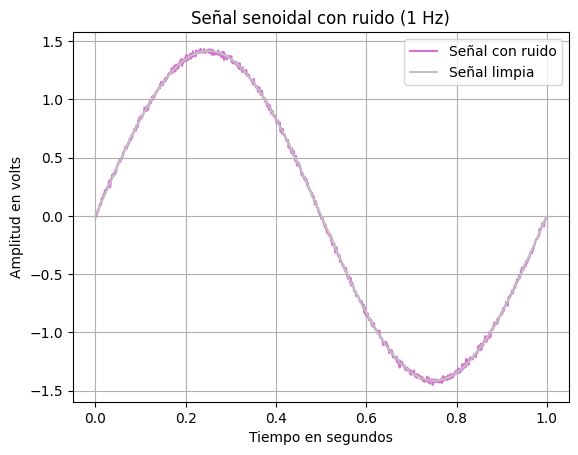

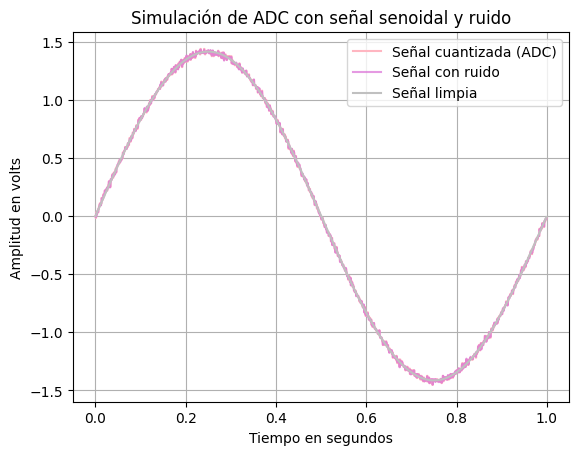

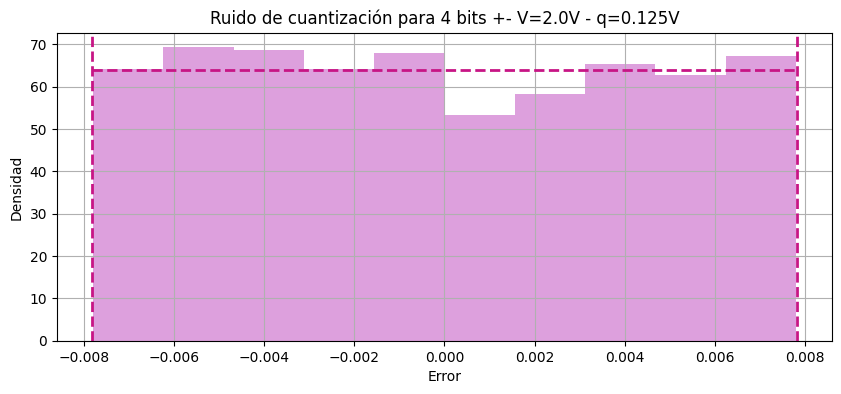

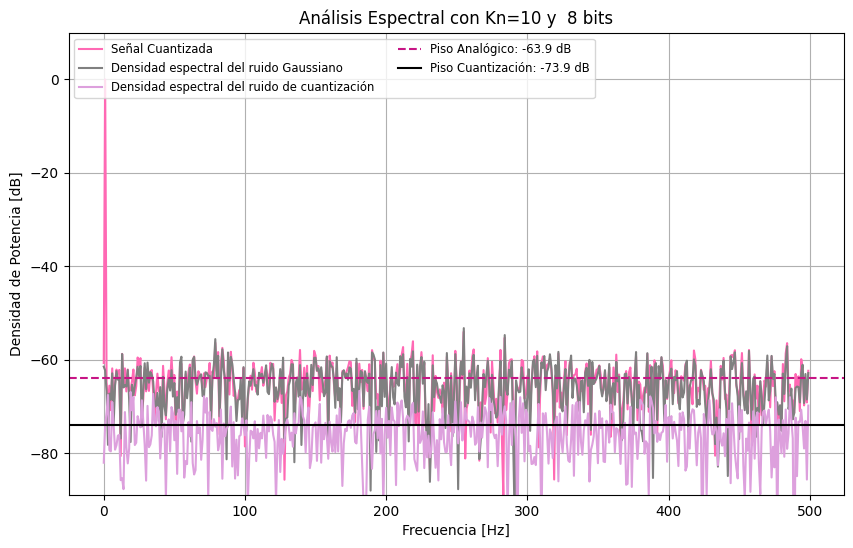

In [39]:
# %% Parámetros del ADC para calcular la potencia de cuantización
B = 8                # bits
VF = 2               # Voltios, rango analógico ±VF
q = (2*VF)/(2**B)    # paso de cuantización
Pq = q**2 / 12       # potencia de cuantización
kn = 10              # factor de escala del ruido
Pn = kn * Pq         # potencia del ruido

# %% Ruido aditivo Gaussiano
ruido = np.random.normal(0, np.sqrt(Pn), nn)
yy = xx + ruido     # Defino la señal con ruido. 


plt.figure()
plt.plot(tt, yy, color='orchid', label='Señal con ruido')
plt.plot(tt, xx, color='silver', label='Señal limpia')
plt.xlabel("Tiempo en segundos")
plt.ylabel("Amplitud en volts")
plt.title(f"Señal senoidal con ruido ({ff} Hz)")
plt.legend()
plt.grid(True)
plt.show()

# Cuantización (simulación del ADC)
yyq = np.round(yy / q) * q  # Redondeo al nivel más cercano, señal cuantizada.

# %% Gráfico comparativo: señal limpia, con ruido y cuantizada
plt.figure()
plt.step(tt, yyq, color='lightpink', where='mid', label='Señal cuantizada (ADC)')
plt.plot(tt, yy, color='orchid', label='Señal con ruido', alpha=0.7)
plt.plot(tt, xx, color='silver', label='Señal limpia')
plt.xlabel("Tiempo en segundos")
plt.ylabel("Amplitud en volts")
plt.title("Simulación de ADC con señal senoidal y ruido")
plt.legend()
plt.grid(True)
plt.show()

#%% ERROR 
ee = yyq - yy  # error sobre señal con ruido

plt.figure(figsize=(10,4))
plt.hist(ee, bins=10, color='plum', density=True) 

# Límites del error
plt.axvline(-q/2, color='mediumvioletred', linestyle='--', linewidth=2)
plt.axvline(q/2, color='mediumvioletred', linestyle='--', linewidth=2)
plt.hlines(1/q, -q/2, q/2, colors='mediumvioletred', linestyles='--', linewidth=2)

plt.title("Ruido de cuantización para 4 bits +- V=2.0V - q=0.125V")
plt.xlabel("Error")
plt.ylabel("Densidad")
plt.grid(True)
plt.show()

# Calculo las FFT de las tres señales
fft_x  = np.fft.fft(xx)   
fft_y  = np.fft.fft(yy)   
fft_yq = np.fft.fft(yyq)  
fftgauss = np.fft.fft(ruido) # Hago la FFT del ruido Gaussiano solo
fftee = np.fft.fft(ee) # Hago la FFT del ruido de cuantización solo


freqs = np.fft.fftfreq(nn, d=1/fs)
mask = freqs >= 0 
fpos = freqs[mask]

def calculardens(f_data, n): 
    dens = (1/n**2) * np.abs(f_data)**2  
    dens[1:-1] *= 2  
    return 10 * np.log10(dens[mask] + 1e-12) 


#Calcula cada densidad
calculardensyq  = calculardens(fft_yq, nn)
calculardensgauss = calculardens(fftgauss, nn)
calculardenscuant = calculardens(fftee, nn)
calculardensyy = calculardens(yy, nn)


# %% GRÁFICO COMPARATIVO FINAL
plt.figure(figsize=(10, 6))

# Grafico la densidad espectral de la cuantizada , que es la que tiene todo. 
plt.plot(fpos, calculardensyq, color='hotpink', label='Señal Cuantizada')

# Grafico la densidad espectral del ruido Gaussiano solo.
plt.plot(fpos, calculardensgauss, color='gray', label='Densidad espectral del ruido Gaussiano')

# Gracuco la densidqad espectral del ruido de cuantización solo.
plt.plot(fpos, calculardenscuant, color='plum', label='Densidad espectral del ruido de cuantización')

# AHORA HAGO LOS PISOS TEÓRICOS

# Para el piso analógico teórico uso solo el Pn
piso_an_teorico = 10 * np.log10(Pn / (nn/2))
plt.axhline(piso_an_teorico, color='mediumvioletred', linestyle='--', label=f'Piso Analógico: {piso_an_teorico:.1f} dB')

# Para el piso de cuantización teórico uso solo el Pq
piso_q_teorico = 10 * np.log10(Pq / (nn/2))
plt.axhline(piso_q_teorico, color='black', label=f'Piso Cuantización: {piso_q_teorico:.1f} dB')

# GRAFICO 
plt.title("Análisis Espectral con Kn=10 y  8 bits")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad de Potencia [dB]")

# Ajusto el límite para que se vean bien los pisos 
plt.ylim([min(piso_an_teorico, piso_q_teorico) - 15, 10]) 
plt.legend(loc='upper left', fontsize='small', ncol=2) #Lo pongo arribita a la derecha para que no me moleste, y con ncol los pongo en 2 columnas.
plt.grid(True)
plt.show()

Como el ruido de cuantización, al aumentar los bits, mejoró tanto, el sistema ya no se halla limitado por este, sino que se encuentra limitado por el ruido analógico.

- Caso C: B = 16 Bits y Kn = 1/10 

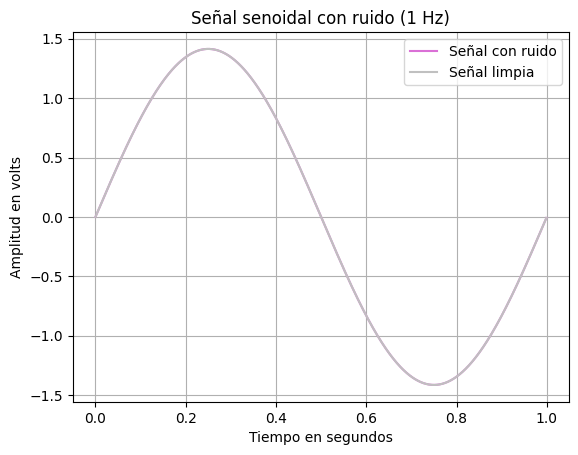

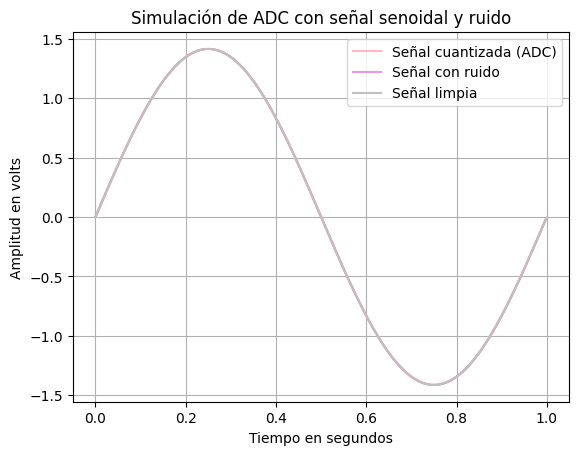

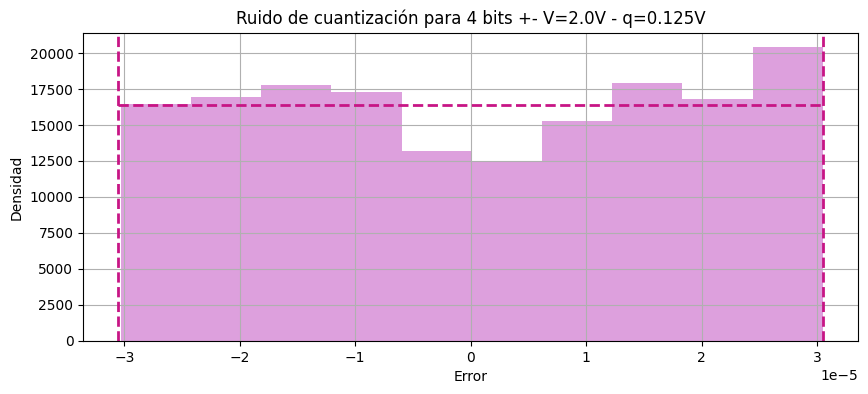

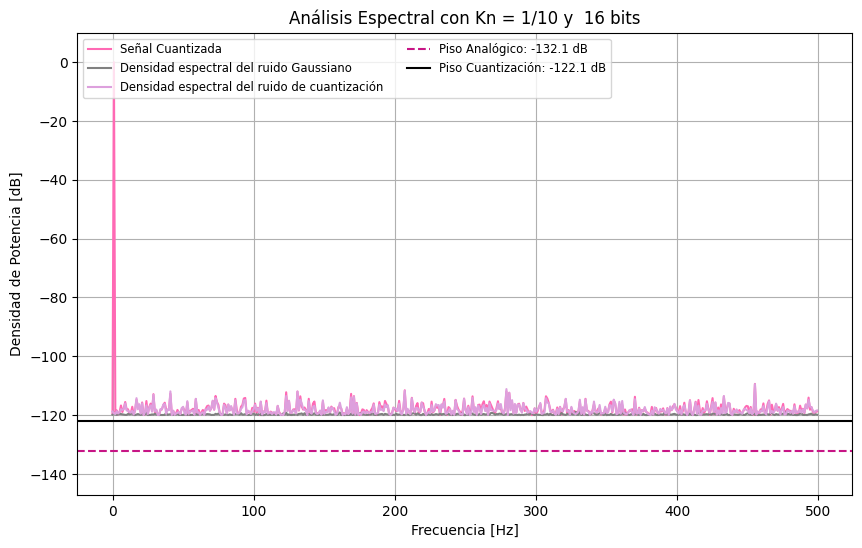

In [38]:
# %% Parámetros del ADC para calcular la potencia de cuantización
B = 16                # bits
VF = 2               # Voltios, rango analógico ±VF
q = (2*VF)/(2**B)    # paso de cuantización
Pq = q**2 / 12       # potencia de cuantización
kn = 1/10              # factor de escala del ruido
Pn = kn * Pq         # potencia del ruido

# %% Ruido aditivo Gaussiano
ruido = np.random.normal(0, np.sqrt(Pn), nn)
yy = xx + ruido     # Defino la señal con ruido. 


plt.figure()
plt.plot(tt, yy, color='orchid', label='Señal con ruido')
plt.plot(tt, xx, color='silver', label='Señal limpia')
plt.xlabel("Tiempo en segundos")
plt.ylabel("Amplitud en volts")
plt.title(f"Señal senoidal con ruido ({ff} Hz)")
plt.legend()
plt.grid(True)
plt.show()

# Cuantización (simulación del ADC)
yyq = np.round(yy / q) * q  # Redondeo al nivel más cercano, señal cuantizada.

# %% Gráfico comparativo: señal limpia, con ruido y cuantizada
plt.figure()
plt.step(tt, yyq, color='lightpink', where='mid', label='Señal cuantizada (ADC)')
plt.plot(tt, yy, color='orchid', label='Señal con ruido', alpha=0.7)
plt.plot(tt, xx, color='silver', label='Señal limpia')
plt.xlabel("Tiempo en segundos")
plt.ylabel("Amplitud en volts")
plt.title("Simulación de ADC con señal senoidal y ruido")
plt.legend()
plt.grid(True)
plt.show()

#%% ERROR 
ee = yyq - yy  # error sobre señal con ruido

plt.figure(figsize=(10,4))
plt.hist(ee, bins=10, color='plum', density=True) 

# Límites del error
plt.axvline(-q/2, color='mediumvioletred', linestyle='--', linewidth=2)
plt.axvline(q/2, color='mediumvioletred', linestyle='--', linewidth=2)
plt.hlines(1/q, -q/2, q/2, colors='mediumvioletred', linestyles='--', linewidth=2)

plt.title("Ruido de cuantización para 4 bits +- V=2.0V - q=0.125V")
plt.xlabel("Error")
plt.ylabel("Densidad")
plt.grid(True)
plt.show()

# Calculo las FFT de las tres señales
fft_x  = np.fft.fft(xx)   
fft_y  = np.fft.fft(yy)   
fft_yq = np.fft.fft(yyq)  
fftgauss = np.fft.fft(ruido) # Hago la FFT del ruido Gaussiano solo
fftee = np.fft.fft(ee) # Hago la FFT del ruido de cuantización solo


freqs = np.fft.fftfreq(nn, d=1/fs)
mask = freqs >= 0 
fpos = freqs[mask]

def calculardens(f_data, n): 
    dens = (1/n**2) * np.abs(f_data)**2  
    dens[1:-1] *= 2  
    return 10 * np.log10(dens[mask] + 1e-12) 


#Calcula cada densidad
calculardensyq  = calculardens(fft_yq, nn)
calculardensgauss = calculardens(fftgauss, nn)
calculardenscuant = calculardens(fftee, nn)
calculardensyy = calculardens(yy, nn)


# %% GRÁFICO COMPARATIVO FINAL
plt.figure(figsize=(10, 6))

# Grafico la densidad espectral de la cuantizada , que es la que tiene todo. 
plt.plot(fpos, calculardensyq, color='hotpink', label='Señal Cuantizada')

# Grafico la densidad espectral del ruido Gaussiano solo.
plt.plot(fpos, calculardensgauss, color='gray', label='Densidad espectral del ruido Gaussiano')

# Gracuco la densidqad espectral del ruido de cuantización solo.
plt.plot(fpos, calculardenscuant, color='plum', label='Densidad espectral del ruido de cuantización')

# AHORA HAGO LOS PISOS TEÓRICOS

# Para el piso analógico teórico uso solo el Pn
piso_an_teorico = 10 * np.log10(Pn / (nn/2))
plt.axhline(piso_an_teorico, color='mediumvioletred', linestyle='--', label=f'Piso Analógico: {piso_an_teorico:.1f} dB')

# Para el piso de cuantización teórico uso solo el Pq
piso_q_teorico = 10 * np.log10(Pq / (nn/2))
plt.axhline(piso_q_teorico, color='black', label=f'Piso Cuantización: {piso_q_teorico:.1f} dB')

# GRAFICO 
plt.title("Análisis Espectral con Kn = 1/10 y  16 bits")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad de Potencia [dB]")

# Ajusto el límite para que se vean bien los pisos 
plt.ylim([min(piso_an_teorico, piso_q_teorico) - 15, 10]) 
plt.legend(loc='upper left', fontsize='small', ncol=2) #Lo pongo arribita a la derecha para que no me moleste, y con ncol los pongo en 2 columnas.
plt.grid(True)
plt.show()

En este caso, el ADC presenta una resoución muy alta, 16 bits, lo que reduce muchísimo el paso de cuantización q, y por lo tanto la potencia del ruido de cuantización. Esto hace que el error de cuantización sea prácticamente despreciable.
Como Kn = 1/10 , el ruido analógico es aún mejor (como se observa en el primer gráfico donde básicamente, ambas señales la original y la ruidosa son iguales, idem con la cuantizada)
Sin embargo, debido a la alta resolución del ADC, ambos ruidos quedan ubicados en niveles muy bajos del espectro, es por ello que en el dominio espectral se observa un piso de ruido extremadamente bajo - alrededor de -120 dB -, donde tanto el ruido analógico como el de cuantización aparecen como señales planas y muy atenuadas, con una diferencia que debería ser de aproximadamente 10 dB.

- Caso C: B = 16 Bits y Kn = 1

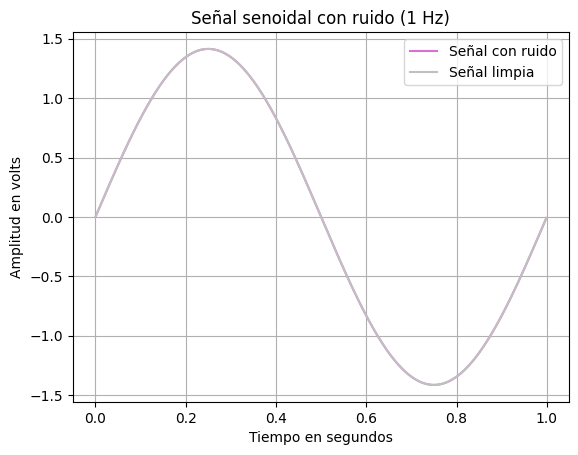

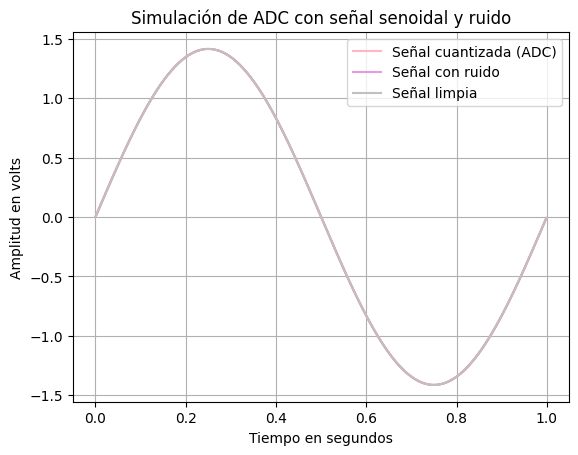

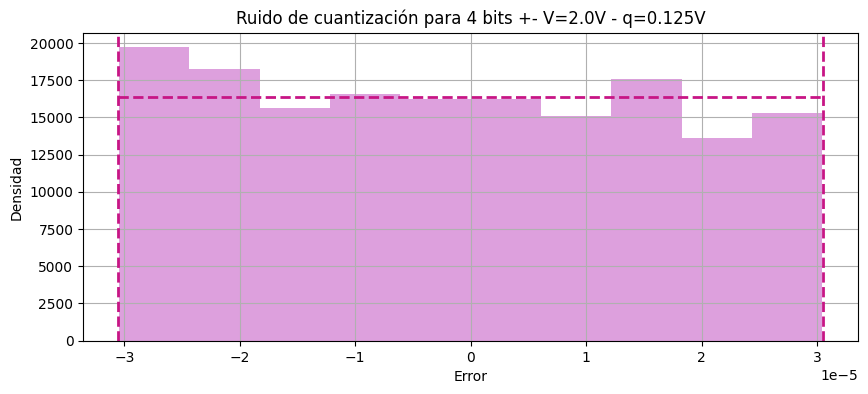

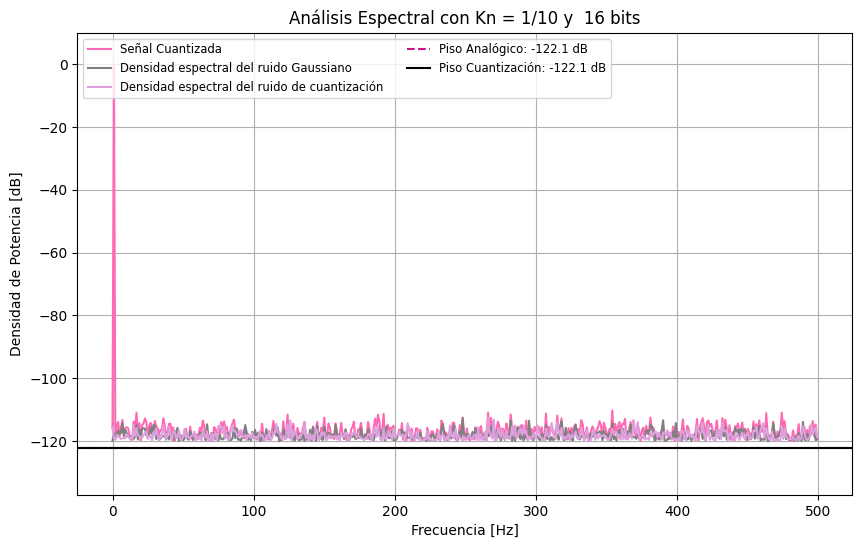

In [43]:
# %% Parámetros del ADC para calcular la potencia de cuantización
B = 16                # bits
VF = 2               # Voltios, rango analógico ±VF
q = (2*VF)/(2**B)    # paso de cuantización
Pq = q**2 / 12       # potencia de cuantización
kn = 1             # factor de escala del ruido
Pn = kn * Pq         # potencia del ruido

# %% Ruido aditivo Gaussiano
ruido = np.random.normal(0, np.sqrt(Pn), nn)
yy = xx + ruido     # Defino la señal con ruido. 


plt.figure()
plt.plot(tt, yy, color='orchid', label='Señal con ruido')
plt.plot(tt, xx, color='silver', label='Señal limpia')
plt.xlabel("Tiempo en segundos")
plt.ylabel("Amplitud en volts")
plt.title(f"Señal senoidal con ruido ({ff} Hz)")
plt.legend()
plt.grid(True)
plt.show()

# Cuantización (simulación del ADC)
yyq = np.round(yy / q) * q  # Redondeo al nivel más cercano, señal cuantizada.

# %% Gráfico comparativo: señal limpia, con ruido y cuantizada
plt.figure()
plt.step(tt, yyq, color='lightpink', where='mid', label='Señal cuantizada (ADC)')
plt.plot(tt, yy, color='orchid', label='Señal con ruido', alpha=0.7)
plt.plot(tt, xx, color='silver', label='Señal limpia')
plt.xlabel("Tiempo en segundos")
plt.ylabel("Amplitud en volts")
plt.title("Simulación de ADC con señal senoidal y ruido")
plt.legend()
plt.grid(True)
plt.show()

#%% ERROR 
ee = yyq - yy  # error sobre señal con ruido

plt.figure(figsize=(10,4))
plt.hist(ee, bins=10, color='plum', density=True) 

# Límites del error
plt.axvline(-q/2, color='mediumvioletred', linestyle='--', linewidth=2)
plt.axvline(q/2, color='mediumvioletred', linestyle='--', linewidth=2)
plt.hlines(1/q, -q/2, q/2, colors='mediumvioletred', linestyles='--', linewidth=2)

plt.title("Ruido de cuantización para 4 bits +- V=2.0V - q=0.125V")
plt.xlabel("Error")
plt.ylabel("Densidad")
plt.grid(True)
plt.show()

# Calculo las FFT de las tres señales
fft_x  = np.fft.fft(xx)   
fft_y  = np.fft.fft(yy)   
fft_yq = np.fft.fft(yyq)  
fftgauss = np.fft.fft(ruido) # Hago la FFT del ruido Gaussiano solo
fftee = np.fft.fft(ee) # Hago la FFT del ruido de cuantización solo


freqs = np.fft.fftfreq(nn, d=1/fs)
mask = freqs >= 0 
fpos = freqs[mask]

def calculardens(f_data, n): 
    dens = (1/n**2) * np.abs(f_data)**2  
    dens[1:-1] *= 2  
    return 10 * np.log10(dens[mask] + 1e-12) 


#Calcula cada densidad
calculardensyq  = calculardens(fft_yq, nn)
calculardensgauss = calculardens(fftgauss, nn)
calculardenscuant = calculardens(fftee, nn)
calculardensyy = calculardens(yy, nn)


# %% GRÁFICO COMPARATIVO FINAL
plt.figure(figsize=(10, 6))

# Grafico la densidad espectral de la cuantizada , que es la que tiene todo. 
plt.plot(fpos, calculardensyq, color='hotpink', label='Señal Cuantizada')

# Grafico la densidad espectral del ruido Gaussiano solo.
plt.plot(fpos, calculardensgauss, color='gray', label='Densidad espectral del ruido Gaussiano')

# Gracuco la densidqad espectral del ruido de cuantización solo.
plt.plot(fpos, calculardenscuant, color='plum', label='Densidad espectral del ruido de cuantización')

# AHORA HAGO LOS PISOS TEÓRICOS

# Para el piso analógico teórico uso solo el Pn
piso_an_teorico = 10 * np.log10(Pn / (nn/2))
plt.axhline(piso_an_teorico, color='mediumvioletred', linestyle='--', label=f'Piso Analógico: {piso_an_teorico:.1f} dB')

# Para el piso de cuantización teórico uso solo el Pq
piso_q_teorico = 10 * np.log10(Pq / (nn/2))
plt.axhline(piso_q_teorico, color='black', label=f'Piso Cuantización: {piso_q_teorico:.1f} dB')

# GRAFICO 
plt.title("Análisis Espectral con Kn = 1/10 y  16 bits")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad de Potencia [dB]")

# Ajusto el límite para que se vean bien los pisos 
plt.ylim([min(piso_an_teorico, piso_q_teorico) - 15, 10]) 
plt.legend(loc='upper left', fontsize='small', ncol=2) #Lo pongo arribita a la derecha para que no me moleste, y con ncol los pongo en 2 columnas.
plt.grid(True)
plt.show()

Ni la cuantización ni el ruido analógico dominan, el piso de ruido total resulta de la combinación de ambos, sin embargo la mejora en resolución del ADC reduce el impacto de la cuantización. 

- Caso C.3: B = 16 Bits y Kn=10

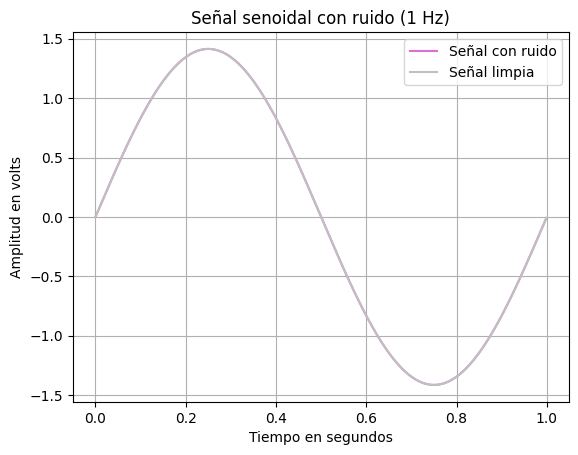

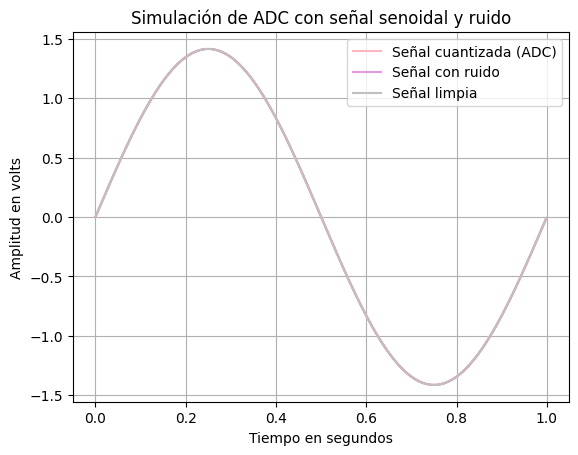

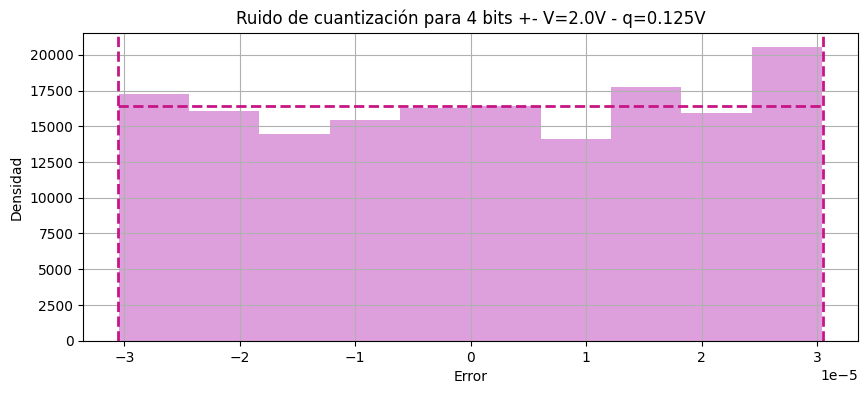

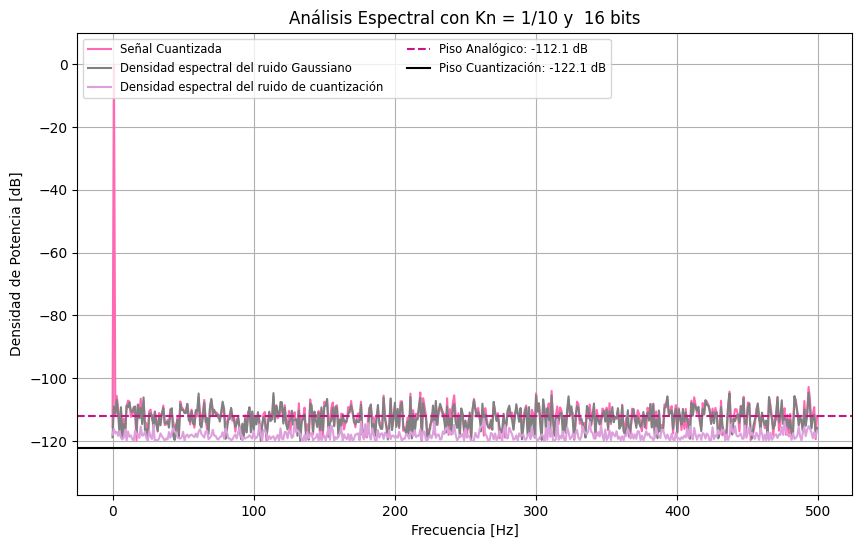

In [45]:
# %% Parámetros del ADC para calcular la potencia de cuantización
B = 16                # bits
VF = 2               # Voltios, rango analógico ±VF
q = (2*VF)/(2**B)    # paso de cuantización
Pq = q**2 / 12       # potencia de cuantización
kn = 10             # factor de escala del ruido
Pn = kn * Pq         # potencia del ruido

# %% Ruido aditivo Gaussiano
ruido = np.random.normal(0, np.sqrt(Pn), nn)
yy = xx + ruido     # Defino la señal con ruido. 


plt.figure()
plt.plot(tt, yy, color='orchid', label='Señal con ruido')
plt.plot(tt, xx, color='silver', label='Señal limpia')
plt.xlabel("Tiempo en segundos")
plt.ylabel("Amplitud en volts")
plt.title(f"Señal senoidal con ruido ({ff} Hz)")
plt.legend()
plt.grid(True)
plt.show()

# Cuantización (simulación del ADC)
yyq = np.round(yy / q) * q  # Redondeo al nivel más cercano, señal cuantizada.

# %% Gráfico comparativo: señal limpia, con ruido y cuantizada
plt.figure()
plt.step(tt, yyq, color='lightpink', where='mid', label='Señal cuantizada (ADC)')
plt.plot(tt, yy, color='orchid', label='Señal con ruido', alpha=0.7)
plt.plot(tt, xx, color='silver', label='Señal limpia')
plt.xlabel("Tiempo en segundos")
plt.ylabel("Amplitud en volts")
plt.title("Simulación de ADC con señal senoidal y ruido")
plt.legend()
plt.grid(True)
plt.show()

#%% ERROR 
ee = yyq - yy  # error sobre señal con ruido

plt.figure(figsize=(10,4))
plt.hist(ee, bins=10, color='plum', density=True) 

# Límites del error
plt.axvline(-q/2, color='mediumvioletred', linestyle='--', linewidth=2)
plt.axvline(q/2, color='mediumvioletred', linestyle='--', linewidth=2)
plt.hlines(1/q, -q/2, q/2, colors='mediumvioletred', linestyles='--', linewidth=2)

plt.title("Ruido de cuantización para 4 bits +- V=2.0V - q=0.125V")
plt.xlabel("Error")
plt.ylabel("Densidad")
plt.grid(True)
plt.show()

# Calculo las FFT de las tres señales
fft_x  = np.fft.fft(xx)   
fft_y  = np.fft.fft(yy)   
fft_yq = np.fft.fft(yyq)  
fftgauss = np.fft.fft(ruido) # Hago la FFT del ruido Gaussiano solo
fftee = np.fft.fft(ee) # Hago la FFT del ruido de cuantización solo


freqs = np.fft.fftfreq(nn, d=1/fs)
mask = freqs >= 0 
fpos = freqs[mask]

def calculardens(f_data, n): 
    dens = (1/n**2) * np.abs(f_data)**2  
    dens[1:-1] *= 2  
    return 10 * np.log10(dens[mask] + 1e-12) 


#Calcula cada densidad
calculardensyq  = calculardens(fft_yq, nn)
calculardensgauss = calculardens(fftgauss, nn)
calculardenscuant = calculardens(fftee, nn)
calculardensyy = calculardens(yy, nn)


# %% GRÁFICO COMPARATIVO FINAL
plt.figure(figsize=(10, 6))

# Grafico la densidad espectral de la cuantizada , que es la que tiene todo. 
plt.plot(fpos, calculardensyq, color='hotpink', label='Señal Cuantizada')

# Grafico la densidad espectral del ruido Gaussiano solo.
plt.plot(fpos, calculardensgauss, color='gray', label='Densidad espectral del ruido Gaussiano')

# Gracuco la densidqad espectral del ruido de cuantización solo.
plt.plot(fpos, calculardenscuant, color='plum', label='Densidad espectral del ruido de cuantización')

# AHORA HAGO LOS PISOS TEÓRICOS

# Para el piso analógico teórico uso solo el Pn
piso_an_teorico = 10 * np.log10(Pn / (nn/2))
plt.axhline(piso_an_teorico, color='mediumvioletred', linestyle='--', label=f'Piso Analógico: {piso_an_teorico:.1f} dB')

# Para el piso de cuantización teórico uso solo el Pq
piso_q_teorico = 10 * np.log10(Pq / (nn/2))
plt.axhline(piso_q_teorico, color='black', label=f'Piso Cuantización: {piso_q_teorico:.1f} dB')

# GRAFICO 
plt.title("Análisis Espectral con Kn = 1/10 y  16 bits")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad de Potencia [dB]")

# Ajusto el límite para que se vean bien los pisos 
plt.ylim([min(piso_an_teorico, piso_q_teorico) - 15, 10]) 
plt.legend(loc='upper left', fontsize='small', ncol=2) #Lo pongo arribita a la derecha para que no me moleste, y con ncol los pongo en 2 columnas.
plt.grid(True)
plt.show()

El ADC sobra, pero se encuentra limitado por a calidad de la señal de entrada.

**BONUS**

A. Encontrar la relación entre la cantidad de B bits del ADC y el SNR de la señal digitalizada. (Ver Holton. DSP Principles and App. 6.7 ADC Quantization pag. 387 )

El SNR (Relación señal - ruido) mide la calidad de la señal. 
Si el SNR es alto, la calidad de la señal respecto al ruido es alta y viceversa. 

En el Holton se estable que: $SNR = 6.02 \cdot B + 1.76$ dB  esta expresión nos dice cuántos decibeles de calidad ganamos mediante los bits que agregamos. Es decir que por cada bit, ganamos 6dB de limpieza. Esto surge a partir de lo siguiente:

La Potencia de la señal ($P_s$) para una senoidal de amplitud $A$, será
$$
P_s = \frac{A^2}{2}.
$$

Sabiendo además que la potencia de cuantización es ($P_q$):
$$
P_q = \frac{q^2}{12},
$$
donde
$$
q = \frac{2 \cdot A}{2^B}.
$$

Al hacer
$$
10 \cdot \log_{10}\left(\frac{P_s}{P_q}\right)
$$
y simplificar los logaritmos, se llega a que:
$$
SNR_{dB} \approx 6.02 \cdot B + 1.76.
$$

Cuando tenía mi ADC de 4bits, el SNR máximo era de aproximadamente 25.8dB, pero cuando aumentamos los bits a 16, se tenía un SNR de aproximadamente 98 dB, es por ello que el ruido de cuantización era casi imperceptible.

B. Simular el efecto del aliasing junto con el muestreo.

El **Aliasing** ocurre cuando no se respeta la frecuencia de Nyquist múltiplemente mencionada: 

$$ 
f_s > 2 \cdot f_{señal}
$$

Por lo que tendré que forzar una frecuencia de muestre inferior a la de Nyquist. 

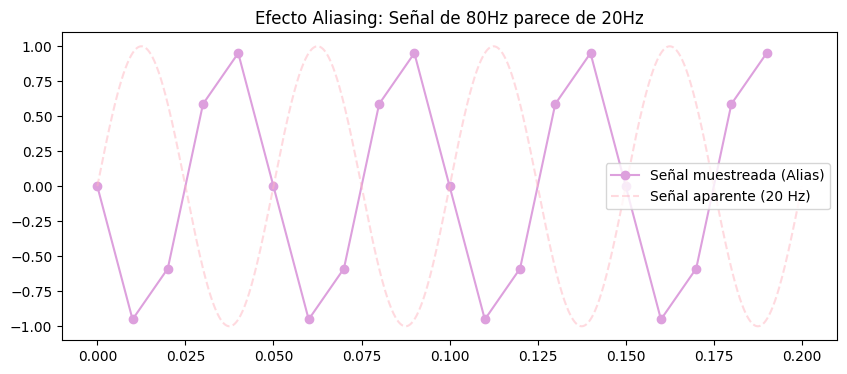

In [59]:
fs_alias = 100        # Disminuyo la frecuencia de muestreo.
ff_alias = 80         # En este caso con una frecuencia de 80 hz, tendré aliasing.
tt_alias = np.arange(0, 0.2, 1/fs_alias) 

xx_alias = np.sin(2 * np.pi * ff_alias * tt_alias)

plt.figure(figsize=(10, 4))
plt.plot(tt_alias, xx_alias, 'o-', label="Señal muestreada (Alias)" , color='plum')
# Dibujo la señal falsa
f_falsa = np.abs(ff_alias - fs_alias) # 80 - 100 = 20 Hz
t_fina = np.linspace(0, 0.2, 1000)
plt.plot(t_fina, np.sin(2 * np.pi * f_falsa * t_fina), '--', alpha=0.5, label=f"Señal aparente ({f_falsa} Hz)", color='lightpink' )

plt.title("Efecto Aliasing: Señal de 80Hz parece de 20Hz")
plt.legend()
plt.show()

Los puntos que el ADC reconoce correctamente, son los que están en violeta. Debido a que el ADC no posee suficientes muestras ya que no tiene una buena frecuencia de muestreo , toma  puntos que están alejados entre sí y la única manera que encuentra de unirlos es creando una señal aparente, de baja frecuencia que pase por dichos puntos.

El Aliasing no es azaroso sino quye sigue una regla matemática. Cuando se supera el límite de Nyquist ($f_s/2 = 50$ Hz), la frecuencia que  se termina viendo -falsa- se calcula como:$$f_{alias} = |f_{real} - f_s|$$$$f_{alias} = |80\text{ Hz} - 100\text{ Hz}| = 20\text{ Hz}$$

Dicha señal es la que se puede observar en el gráfico, de color rosita claro.

Los bits controlan qué tan "limpia" se ve la señal, el muestreo controla qué tan reales son las frecuencias, por ello si se tiene Aliasing, de nada sirve tener el mejor ADC del mundo con más resolución, si lo que se va a mostrar es una señal que no existe.

Me resultó interesante ver qué pasaba si le calculaba la FFT y la densidad de potencias a la señal aparente (la trucha). Tuve problemas para ver el efecto de Aliasing, la IA me explicó que al tener una frecuencia "cómoda" era difícil de observar el efecto, así que lo que había que hacer era añadirle una interferencia grande.

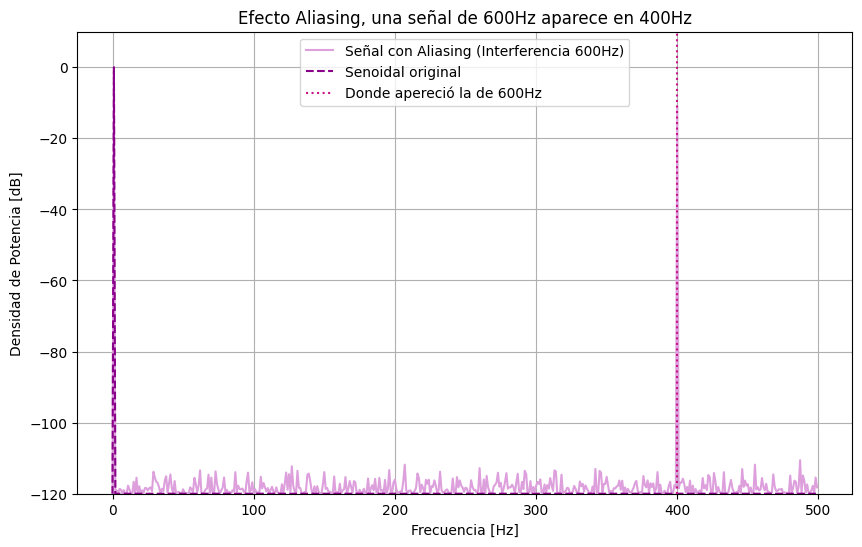

In [70]:
#Simulación de Aliasing 

# Uso la misma señal, pero le agrego una interferencia de 600hz, lo suficientemente alta para poder observar el efecto. 
f_ruido_rapido = 600  
interferencia = 0.4 * np.sin(2 * np.pi * f_ruido_rapido * tt)

# Mi señal será ahora la orginal más la interferencia
xxconproblemas = xx + interferencia 

# 2. Tu proceso de siempre: Cuantización (B=8)
yyqconalias = np.round(xxconproblemas / q) * q

# 3. Calculamos la densidad espectral (PSD)
fftconalias = np.fft.fft(yyqconalias)
psdconalias = calculardens(fftconalias, nn)

# --- GRÁFICO COMPARATIVO ---
plt.figure(figsize=(10, 6))

# Graficamos la señal con el problema (la roja)
plt.plot(fpos, psdconalias, color='plum', label='Señal con Aliasing (Interferencia 600Hz)')

# Graficamos tu senoidal original de 1Hz (la de siempre para comparar)
plt.plot(fpos, calculardensxx, color='darkmagenta', linestyle='--', label='Senoidal original')

# Marcamos el "rebote" (Alias) en 400 Hz
plt.axvline(400, color='mediumvioletred', linestyle=':', label='Donde apereció la de 600Hz')

plt.title("Efecto Aliasing, una señal de 600Hz aparece en 400Hz")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad de Potencia [dB]")
plt.ylim([-120, 10])
plt.legend()
plt.grid(True)
plt.show()

Una vez que una señal de alta frecuencia, como la de 600Hz,  ingresa al ADC y se convierte en un alias, como se pudo observar en los 400 Hz, ya no se puede borrar. Para el sistema esos 400 Hz son "reales", es por ello que resulta fundamental tener un buen filtro antialias,  protege el SNR ya que al filtrar el ruido de alta frecuencia se manteniel piso de ruido lo más bajo posible.

Nuevamente, de nada sirve tener la mejor resolución del ADC, para que solo procese información si esa información no es fidedigna y de calidad.